# PEAD Project - Data Collection & Initial EDA
**Post-Earnings Announcement Drift: Multimodal ML Framework for S&P 500 Stocks**

## Pipeline Execution

In [3]:
# Run the full pipeline
from pead_pipeline import run_pipeline

# For all S&P 500 stocks:
modeling, daily = run_pipeline()


------------------------------------------------------------
Running pipeline for: ALL STOCKS
------------------------------------------------------------

- Loading data from S3 -
Earnings loaded: (24294, 12) | Symbols: 503
Transcripts loaded: (20653, 13) | Symbols: 500
OHLCV loaded: (4385666, 7) | Symbols: 503

- EPS & transcript features -
EPS features added for 503 symbols
Transcript features added for 500 symbols

 - Processing 503 symbols in 11 batches -

- Batch 1/11 (50 symbols) -
  TA indicators: 50/50 symbols
  Event windows: 50/50 symbols | 2419 events

Total: 2419 events | 5 skipped | shape: (29028, 22)
Pivoted: 2419 events × 218 columns

- Batch 2/11 (50 symbols) -
  TA indicators: 50/50 symbols
  Event windows: 50/50 symbols | 2434 events

Total: 2434 events | 2 skipped | shape: (29208, 22)
Pivoted: 2434 events × 218 columns

- Batch 3/11 (50 symbols) -
  TA indicators: 50/50 symbols
  Event windows: 50/50 symbols | 2318 events

Total: 2318 events | 40 skipped | shape: (2

In [4]:
# import libraries
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pl.Config.set_fmt_str_lengths(50)


polars.config.Config

### Dataset Overview

In [5]:
# Dataset overview
print(f"Final modeling table: {modeling.shape[0]} events × {modeling.shape[1]} columns")
print(f"Symbols covered: {modeling['symbol'].n_unique()}")
print(f"Date range: {modeling['earnings_date'].min()} to {modeling['earnings_date'].max()}")
print(f"Total nulls: {modeling.null_count().sum_horizontal()[0]}")

# Events per symbol
event_counts = modeling.group_by("symbol").len().sort("len")
print(f"\nEvents per symbol:")
print(f"  Min: {event_counts['len'].min()}")
print(f"  Median: {event_counts['len'].median()}")
print(f"  Max: {event_counts['len'].max()}")

# Stocks with fewer than 10 events
low = event_counts.filter(pl.col("len") < 10)
if low.shape[0] > 0:
    print(f"\n {low.shape[0]} stocks with < 10 events (may be insufficient for modeling):")
    print(low.head(10))


Final modeling table: 24161 events × 236 columns
Symbols covered: 503
Date range: 2014-01-07 to 2026-05-28
Total nulls: 11878

Events per symbol:
  Min: 2
  Median: 50.0
  Max: 50

 4 stocks with < 10 events (may be insufficient for modeling):
shape: (4, 2)
┌────────┬─────┐
│ symbol ┆ len │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ Q      ┆ 2   │
│ SNDK   ┆ 6   │
│ GEV    ┆ 9   │
│ SOLV   ┆ 9   │
└────────┴─────┘


### Data Types Summary

In [6]:
# Categorize columns
pivoted_cols = [c for c in modeling.columns if re.search(r"_t[+-]?\d+$", c)]
event_cols = [c for c in modeling.columns if c not in pivoted_cols]

print(f"Pivoted (time-series) columns: {len(pivoted_cols)}")
print(f"Event-level columns: {len(event_cols)}")
print(f"\nEvent-level column details:")
print("-" * 60)
for col in event_cols:
    null_pct = round(100 * modeling[col].null_count() / modeling.shape[0], 1)
    print(f"  {col:30s}  {str(modeling[col].dtype):15s}  nulls: {null_pct}%")


Pivoted (time-series) columns: 216
Event-level columns: 20

Event-level column details:
------------------------------------------------------------
  symbol                          String           nulls: 0.0%
  earnings_date                   Date             nulls: 0.0%
  fiscalDateEnding                Date             nulls: 0.0%
  reportedDate                    Date             nulls: 0.0%
  reportedEPS                     Float64          nulls: 0.0%
  estimatedEPS                    Float64          nulls: 0.3%
  surprise                        Float64          nulls: 0.0%
  surprisePercentage              Float64          nulls: 0.4%
  reportTime                      String           nulls: 0.0%
  fiscal_month                    Int8             nulls: 0.0%
  fiscal_year                     Int32            nulls: 0.0%
  av_quarter                      String           nulls: 0.0%
  time_from                       String           nulls: 0.0%
  eps_growth                    

### Scale Validation
Verify that every earnings event produced exactly 12 daily rows (t-10 through t+1).


In [7]:
# Scale validation
rows_per_event = daily.group_by("symbol", "earnings_date").len()
bad = rows_per_event.filter(pl.col("len") != 12)

if bad.shape[0] > 0:
    print(f"{bad.shape[0]} events without exactly 12 rows:")
    print(bad.head(10))
else:
    print(" All events have exactly 12 rows (t-10 through t+1)")

print(f"\nDaily table: {daily.shape}")
print(f"Modeling table: {modeling.shape}")


 All events have exactly 12 rows (t-10 through t+1)

Daily table: (289932, 22)
Modeling table: (24161, 236)


## Descriptive Statistics

### OHLCV & Technical Indicators at t0


In [8]:
# Descriptive stats for key features at t0
t0_cols = sorted([c for c in modeling.columns if c.endswith("_t0")])
print(f"Features at t0: {len(t0_cols)} columns")
print(modeling.select(t0_cols).describe())


Features at t0: 18 columns
shape: (9, 19)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ atr_t0    ┆ bb_lower_ ┆ bb_middle ┆ … ┆ open_t0   ┆ rsi_t0    ┆ volume_ch ┆ volume_t │
│ ---       ┆ ---       ┆ t0        ┆ _t0       ┆   ┆ ---       ┆ ---       ┆ ange_t0   ┆ 0        │
│ str       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ f64       ┆ f64       ┆ ---       ┆ ---      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆           ┆           ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 24161.0   ┆ 24161.0   ┆ 24161.0   ┆ … ┆ 24161.0   ┆ 24161.0   ┆ 24161.0   ┆ 24161.0  │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ NaN       ┆ NaN       ┆ NaN       ┆

### Earnings Fundamentals


In [9]:
# Earnings descriptive stats
print(modeling.select(
    "reportedEPS", "estimatedEPS", "surprise", "surprisePercentage"
).describe())


shape: (9, 5)
┌────────────┬─────────────┬──────────────┬──────────┬────────────────────┐
│ statistic  ┆ reportedEPS ┆ estimatedEPS ┆ surprise ┆ surprisePercentage │
│ ---        ┆ ---         ┆ ---          ┆ ---      ┆ ---                │
│ str        ┆ f64         ┆ f64          ┆ f64      ┆ f64                │
╞════════════╪═════════════╪══════════════╪══════════╪════════════════════╡
│ count      ┆ 24158.0     ┆ 24096.0      ┆ 24161.0  ┆ 24067.0            │
│ null_count ┆ 3.0         ┆ 65.0         ┆ 0.0      ┆ 94.0               │
│ mean       ┆ 1.5964      ┆ 1.501503     ┆ 0.096931 ┆ 11.5906            │
│ std        ┆ 4.075134    ┆ 3.864262     ┆ 0.599964 ┆ 283.517531         │
│ min        ┆ -18.39      ┆ -17.42       ┆ -14.58   ┆ -8600.0            │
│ 25%        ┆ 0.51        ┆ 0.48         ┆ 0.0      ┆ 0.0                │
│ 50%        ┆ 1.01        ┆ 0.95         ┆ 0.04     ┆ 4.5977             │
│ 75%        ┆ 1.84        ┆ 1.72         ┆ 0.13     ┆ 12.5               

### Distribution Shape - Skewness & Kurtosis

In [10]:
# Skewness, kurtosis, and Shapiro-Wilk normality test
from scipy import stats

dist_cols = ["surprise", "surprisePercentage", "close_t0", "volume_t0",
             "rsi_t0", "daily_return_t0", "atr_t0", "macd_t0",
             "eps_growth", "transcript_word_count"]
dist_cols = [c for c in dist_cols if c in modeling.columns]

dist_results = []
for col in dist_cols:
    vals = modeling[col].drop_nulls().to_numpy()
    skew = float(stats.skew(vals))
    kurt = float(stats.kurtosis(vals))
    _, p_val = stats.shapiro(vals) if len(vals) <= 5000 else stats.normaltest(vals)
    dist_results.append({
        "feature": col,
        "skewness": round(skew, 3),
        "kurtosis": round(kurt, 3),
        "p_value": round(p_val, 4),
        "normal": "Yes" if p_val > 0.05 else "No"
    })

print("Distribution shape analysis (α = 0.05):")
print(pl.DataFrame(dist_results))


Distribution shape analysis (α = 0.05):
shape: (10, 5)
┌───────────────────────┬──────────┬──────────┬─────────┬────────┐
│ feature               ┆ skewness ┆ kurtosis ┆ p_value ┆ normal │
│ ---                   ┆ ---      ┆ ---      ┆ ---     ┆ ---    │
│ str                   ┆ f64      ┆ f64      ┆ f64     ┆ str    │
╞═══════════════════════╪══════════╪══════════╪═════════╪════════╡
│ surprise              ┆ 11.106   ┆ 654.338  ┆ 0.0     ┆ No     │
│ surprisePercentage    ┆ 71.261   ┆ 8717.372 ┆ 0.0     ┆ No     │
│ close_t0              ┆ 17.366   ┆ 435.363  ┆ 0.0     ┆ No     │
│ volume_t0             ┆ 15.223   ┆ 325.074  ┆ 0.0     ┆ No     │
│ rsi_t0                ┆ NaN      ┆ NaN      ┆ NaN     ┆ No     │
│ daily_return_t0       ┆ -0.172   ┆ 7.055    ┆ 0.0     ┆ No     │
│ atr_t0                ┆ NaN      ┆ NaN      ┆ NaN     ┆ No     │
│ macd_t0               ┆ NaN      ┆ NaN      ┆ NaN     ┆ No     │
│ eps_growth            ┆ NaN      ┆ NaN      ┆ NaN     ┆ No     │
│ trans

## Missing Value Analysis


In [11]:
# Missing values audit
total_cells = modeling.shape[0] * modeling.shape[1]
total_nulls = modeling.null_count().sum_horizontal()[0]
print(f"Total cells: {total_cells:,}")
print(f"Total nulls: {total_nulls:,} ({100 * total_nulls / total_cells:.2f}%)")

# Per-column breakdown (only columns with nulls)
cols_with_nulls = []
for c in modeling.columns:
    n = modeling[c].null_count()
    if n > 0:
        cols_with_nulls.append({
            "column": c,
            "nulls": n,
            "pct": round(100 * n / modeling.shape[0], 2)
        })

if cols_with_nulls:
    print("\nColumns with missing values:")
    print(pl.DataFrame(cols_with_nulls).sort("nulls", descending=True))
else:
    print("\nNo missing values found in any column")


Total cells: 5,701,996
Total nulls: 11,878 (0.21%)

Columns with missing values:
shape: (11, 3)
┌───────────────────────┬───────┬───────┐
│ column                ┆ nulls ┆ pct   │
│ ---                   ┆ ---   ┆ ---   │
│ str                   ┆ i64   ┆ f64   │
╞═══════════════════════╪═══════╪═══════╡
│ transcript            ┆ 3644  ┆ 15.08 │
│ transcript_word_count ┆ 3564  ┆ 14.75 │
│ transcript_char_count ┆ 3564  ┆ 14.75 │
│ eps_growth            ┆ 472   ┆ 1.95  │
│ surprise_trend        ┆ 469   ┆ 1.94  │
│ …                     ┆ …     ┆ …     │
│ estimatedEPS          ┆ 65    ┆ 0.27  │
│ reportedEPS           ┆ 3     ┆ 0.01  │
│ daily_return_t-10     ┆ 1     ┆ 0.0   │
│ gap_t-10              ┆ 1     ┆ 0.0   │
│ volume_change_t-10    ┆ 1     ┆ 0.0   │
└───────────────────────┴───────┴───────┘


In [12]:
# Duplicate event check
dupe_count = modeling.select("symbol", "earnings_date").is_duplicated().sum()
print(f"Duplicate events (same symbol + earnings_date): {dupe_count}")

if dupe_count > 0:
    dupes = modeling.filter(
        pl.struct("symbol", "earnings_date").is_duplicated()
    ).select("symbol", "earnings_date").unique()
    print("Duplicate event details:")
    print(dupes)
else:
    print("No duplicate events — each (symbol, earnings_date) pair is unique")

Duplicate events (same symbol + earnings_date): 0
No duplicate events — each (symbol, earnings_date) pair is unique


## Outlier Detection (IQR Method)

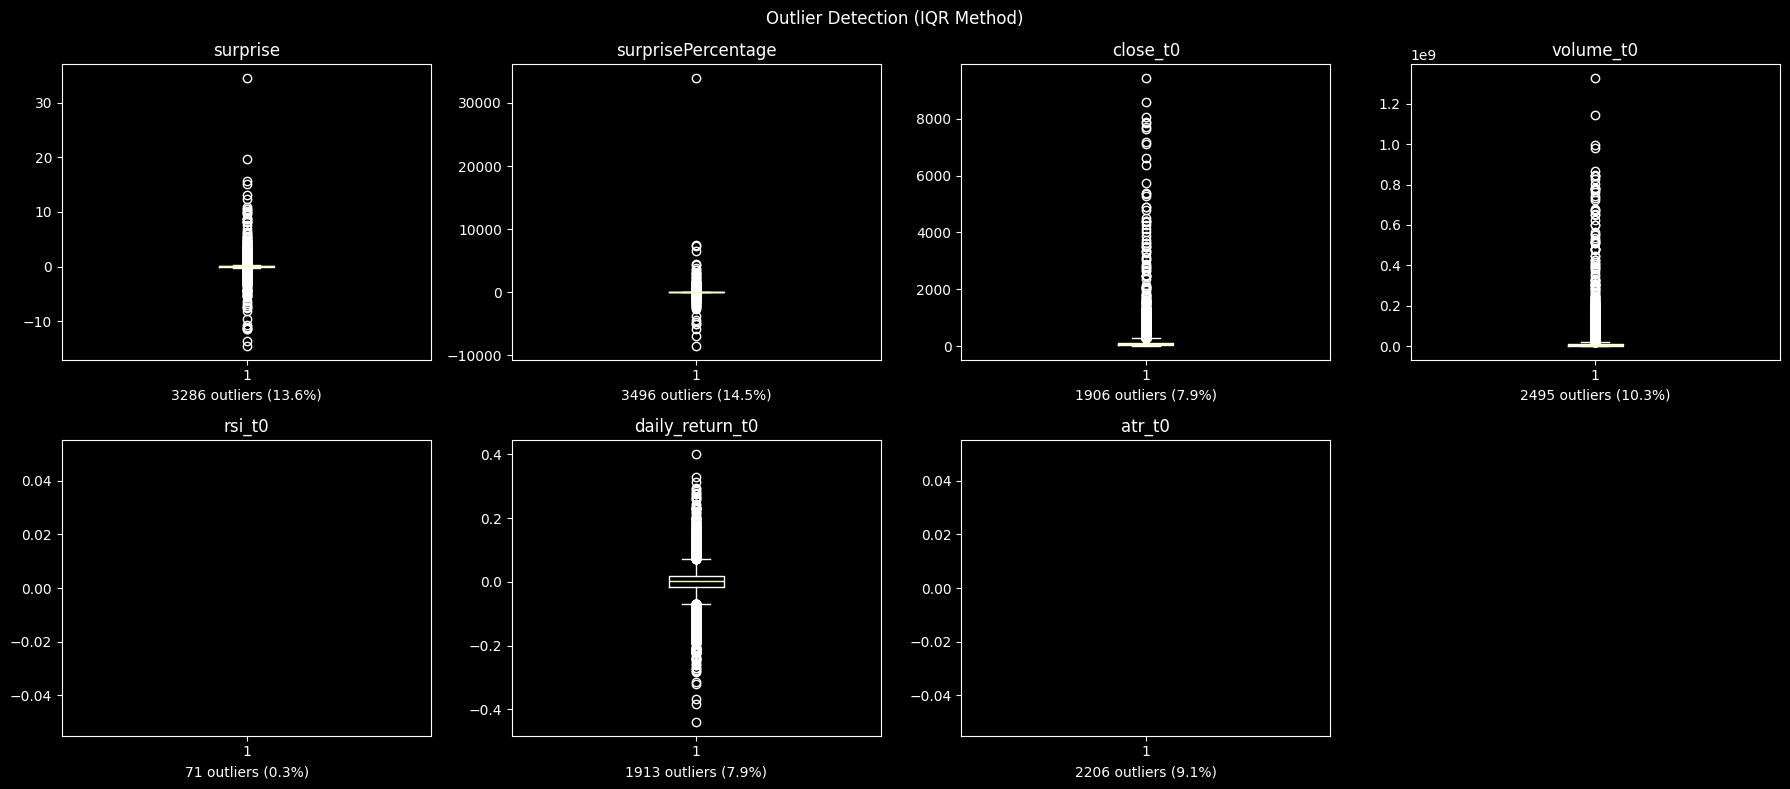

In [13]:
# Box plots with IQR-based outlier counts
check_cols = ["surprise", "surprisePercentage", "close_t0", "volume_t0",
              "rsi_t0", "daily_return_t0", "atr_t0"]
check_cols = [c for c in check_cols if c in modeling.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    vals = modeling[col].drop_nulls().to_list()
    axes[i].boxplot(vals)
    axes[i].set_title(col)

    q1, q3 = modeling[col].quantile(0.25), modeling[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = modeling.filter(
        (pl.col(col) < q1 - 1.5 * iqr) | (pl.col(col) > q3 + 1.5 * iqr)
    ).shape[0]
    axes[i].set_xlabel(f"{n_outliers} outliers ({100*n_outliers/modeling.shape[0]:.1f}%)")

for j in range(len(check_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Detection (IQR Method)")
plt.tight_layout()
plt.show()


## Correlation & Relationship Analysis

### Correlation Heatmap at t0

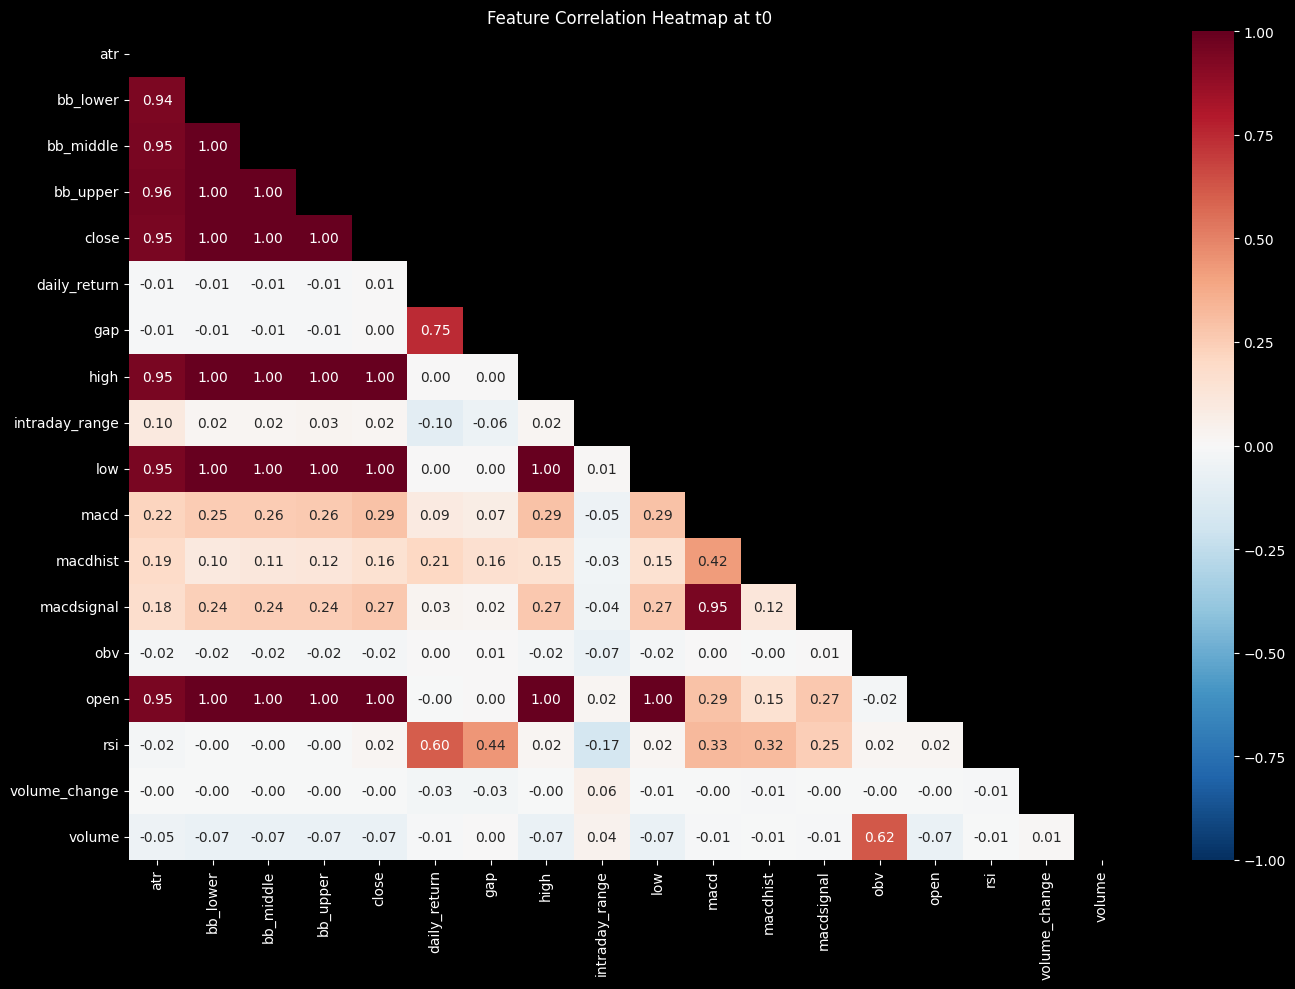


Highly correlated pairs (|r| > 0.90):
  atr_t0               ↔ bb_lower_t0           r = +0.944
  atr_t0               ↔ bb_middle_t0          r = +0.951
  atr_t0               ↔ bb_upper_t0           r = +0.956
  atr_t0               ↔ close_t0              r = +0.951
  atr_t0               ↔ high_t0               r = +0.952
  atr_t0               ↔ low_t0                r = +0.950
  atr_t0               ↔ open_t0               r = +0.951
  bb_lower_t0          ↔ bb_middle_t0          r = +0.999
  bb_lower_t0          ↔ bb_upper_t0           r = +0.998
  bb_lower_t0          ↔ close_t0              r = +0.998
  bb_lower_t0          ↔ high_t0               r = +0.998
  bb_lower_t0          ↔ low_t0                r = +0.998
  bb_lower_t0          ↔ open_t0               r = +0.998
  bb_middle_t0         ↔ bb_upper_t0           r = +1.000
  bb_middle_t0         ↔ close_t0              r = +0.999
  bb_middle_t0         ↔ high_t0               r = +0.999
  bb_middle_t0         ↔ low_t0  

In [14]:
# Correlation heatmap at t0
t0_cols = sorted([c for c in modeling.columns if c.endswith("_t0")])
t0_data = modeling.select(t0_cols).to_pandas()

fig, ax = plt.subplots(figsize=(14, 10))
corr = t0_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, vmin=-1, vmax=1,
            xticklabels=[c.replace("_t0", "") for c in t0_cols],
            yticklabels=[c.replace("_t0", "") for c in t0_cols])
ax.set_title("Feature Correlation Heatmap at t0")
plt.tight_layout()
plt.show()

# Highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.90):")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.90:
            print(f"  {corr.columns[i]:20s} ↔ {corr.columns[j]:20s}  r = {r:+.3f}")


### Temporal Autocorrelation by Feature Group

In [15]:
# Temporal autocorrelation
feature_groups = {}
for col in pivoted_cols:
    base = re.sub(r"_t[+-]?\d+$", "", col)
    feature_groups.setdefault(base, []).append(col)

print("Feature groups and temporal correlation:")
for name, cols in sorted(feature_groups.items()):
    if len(cols) > 1:
        corr_matrix = modeling.select(cols).to_pandas().corr()
        avg_corr = (corr_matrix.values.sum() - len(cols)) / (len(cols) * (len(cols) - 1))
        print(f"  {name:20s}: {len(cols)} features | Avg pairwise corr: {avg_corr:.2f}")


Feature groups and temporal correlation:
  atr                 : 12 features | Avg pairwise corr: 0.99
  bb_lower            : 12 features | Avg pairwise corr: 1.00
  bb_middle           : 12 features | Avg pairwise corr: 1.00
  bb_upper            : 12 features | Avg pairwise corr: 1.00
  close               : 12 features | Avg pairwise corr: 1.00
  daily_return        : 12 features | Avg pairwise corr: -0.01
  gap                 : 12 features | Avg pairwise corr: -0.01
  high                : 12 features | Avg pairwise corr: 1.00
  intraday_range      : 12 features | Avg pairwise corr: 0.46
  low                 : 12 features | Avg pairwise corr: 1.00
  macd                : 12 features | Avg pairwise corr: 0.87
  macdhist            : 12 features | Avg pairwise corr: 0.65
  macdsignal          : 12 features | Avg pairwise corr: 0.92
  obv                 : 12 features | Avg pairwise corr: 1.00
  open                : 12 features | Avg pairwise corr: 1.00
  rsi                 : 12 

## Class Distribution Analysis

Overall class distribution:
shape: (2, 2)
┌───────────┬───────┐
│ beat_flag ┆ len   │
│ ---       ┆ ---   │
│ i8        ┆ u32   │
╞═══════════╪═══════╡
│ 0         ┆ 6448  │
│ 1         ┆ 17713 │
└───────────┴───────┘

Overall beat rate: 73.3%


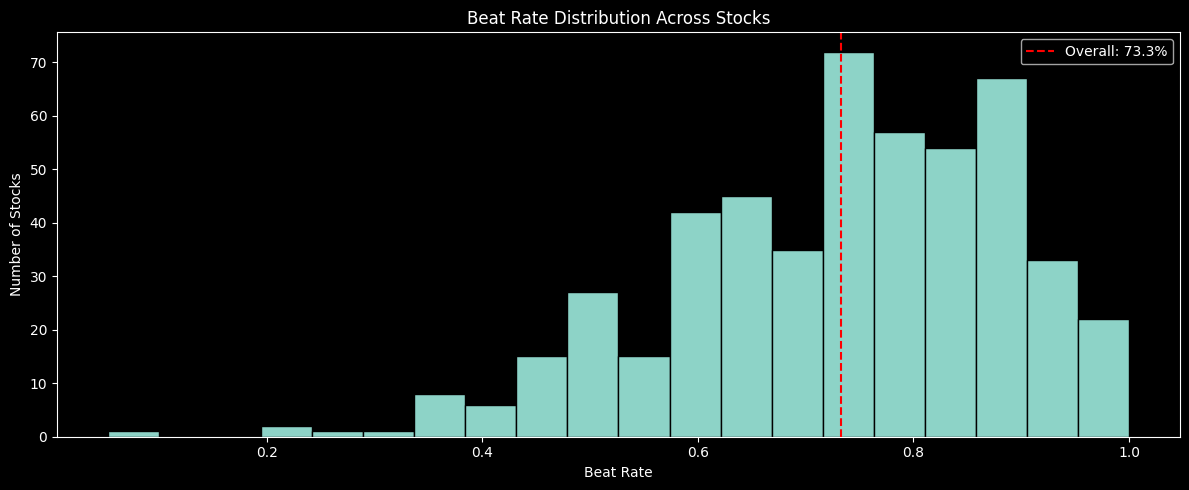

In [16]:
# Class balance
modeling = modeling.with_columns(
    (pl.col("surprise").cast(pl.Float64) > 0).cast(pl.Int8).alias("beat_flag")
)

beat_dist = modeling.group_by("beat_flag").len().sort("beat_flag")
print("Overall class distribution:")
print(beat_dist)

beat_rate = modeling["beat_flag"].mean()
print(f"\nOverall beat rate: {beat_rate:.1%}")

# Beat rate by symbol (check for per-stock imbalance)
per_stock = modeling.group_by("symbol").agg([
    pl.col("beat_flag").mean().alias("beat_rate"),
    pl.len().alias("events"),
]).sort("beat_rate")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(per_stock["beat_rate"].to_list(), bins=20, edgecolor="black")
ax.axvline(x=beat_rate, color="red", linestyle="--", label=f"Overall: {beat_rate:.1%}")
ax.set_title("Beat Rate Distribution Across Stocks")
ax.set_xlabel("Beat Rate")
ax.set_ylabel("Number of Stocks")
ax.legend()
plt.tight_layout()
plt.show()


## PEAD Signal Analysis

### Average Price Path - Beat vs Miss

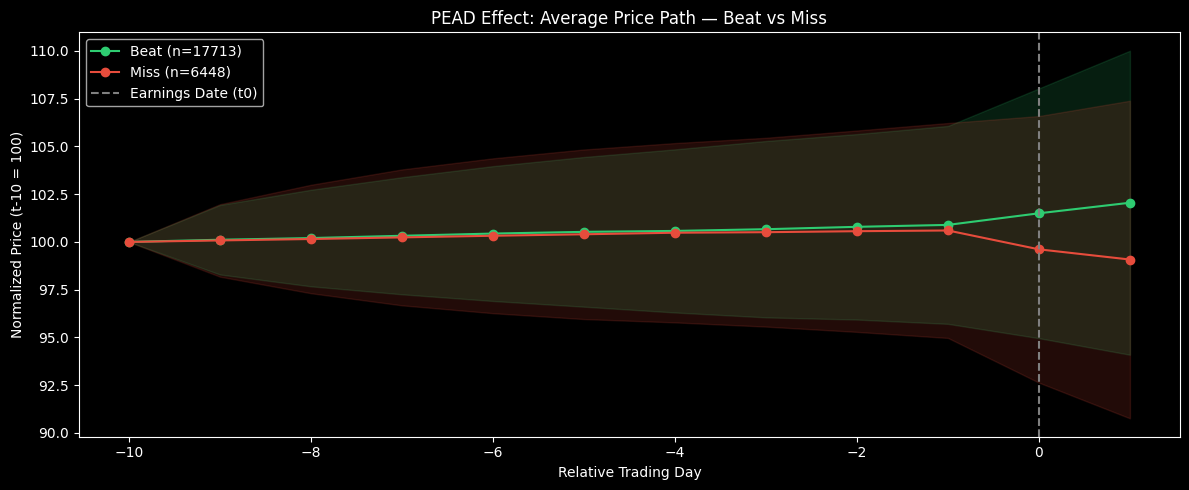

In [17]:
# PEAD: average price path by beat vs miss
close_cols = sorted(
    [c for c in modeling.columns if c.startswith("close_t")],
    key=lambda c: int(c.split("_t")[1].replace("+", ""))
)
days = list(range(-10, 2))

fig, ax = plt.subplots(figsize=(12, 5))

for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
    group = modeling.filter(pl.col("beat_flag") == flag)

    # extract entire matrix at once, normalize in numpy
    prices = group.select(close_cols).to_numpy()
    base = prices[:, 0:1]  # first column as (n, 1) for broadcasting
    mask = (base > 0).flatten()
    normalized = (prices[mask] / base[mask]) * 100

    avg_path = np.mean(normalized, axis=0)
    std_path = np.std(normalized, axis=0)

    ax.plot(days, avg_path, marker="o", label=f"{label} (n={len(normalized)})", color=color)
    ax.fill_between(days, avg_path - std_path, avg_path + std_path, alpha=0.15, color=color)

ax.axvline(x=0, color="gray", linestyle="--", label="Earnings Date (t0)")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Normalized Price (t-10 = 100)")
ax.set_title("PEAD Effect: Average Price Path — Beat vs Miss")
ax.legend()
plt.tight_layout()
plt.show()

### Announcement-Day & Post-Announcement Returns


Returns by earnings surprise direction:
shape: (2, 6)
┌───────────┬───────────────┬────────────────┬───────────────┬────────────────┬───────┐
│ beat_flag ┆ avg_return_t0 ┆ avg_return_t+1 ┆ std_return_t0 ┆ std_return_t+1 ┆ count │
│ ---       ┆ ---           ┆ ---            ┆ ---           ┆ ---            ┆ ---   │
│ i8        ┆ f64           ┆ f64            ┆ f64           ┆ f64            ┆ u32   │
╞═══════════╪═══════════════╪════════════════╪═══════════════╪════════════════╪═══════╡
│ 0         ┆ -0.009767     ┆ -0.00531       ┆ 0.043165      ┆ 0.045919       ┆ 6448  │
│ 1         ┆ 0.006065      ┆ 0.005472       ┆ 0.039829      ┆ 0.044802       ┆ 17713 │
└───────────┴───────────────┴────────────────┴───────────────┴────────────────┴───────┘


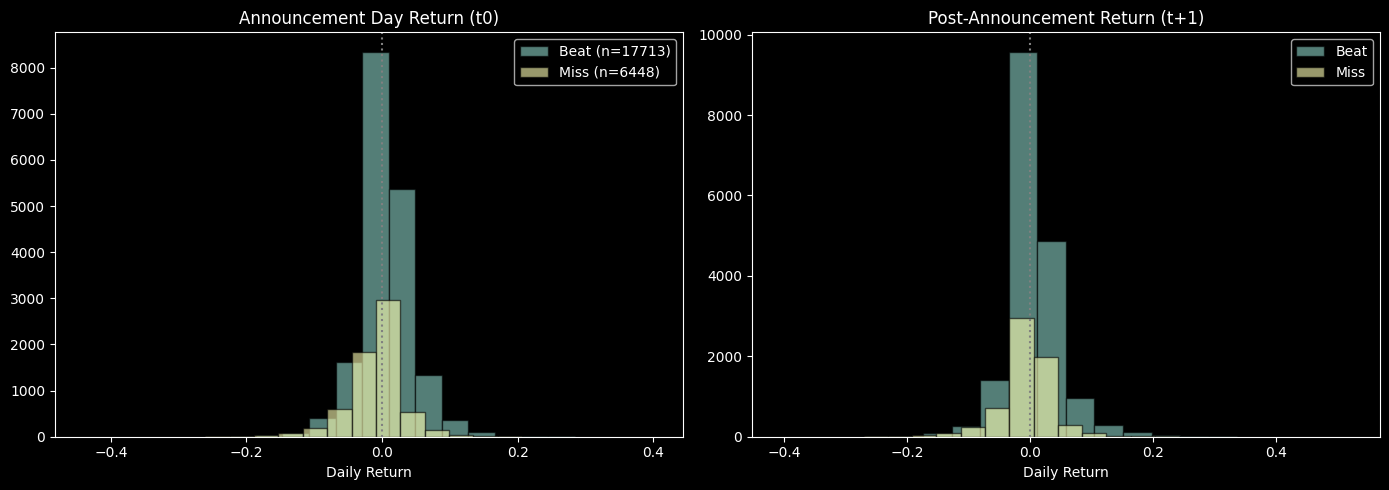

In [18]:
# Return distributions by beat/miss
return_summary = modeling.group_by("beat_flag").agg([
    pl.col("daily_return_t0").mean().alias("avg_return_t0"),
    pl.col("daily_return_t+1").mean().alias("avg_return_t+1"),
    pl.col("daily_return_t0").std().alias("std_return_t0"),
    pl.col("daily_return_t+1").std().alias("std_return_t+1"),
    pl.len().alias("count"),
]).sort("beat_flag")
print("Returns by earnings surprise direction:")
print(return_summary)

beats = modeling.filter(pl.col("beat_flag") == 1)
misses = modeling.filter(pl.col("beat_flag") == 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(beats["daily_return_t0"].drop_nulls().to_list(), bins=20, alpha=0.6,
             label=f"Beat (n={beats.shape[0]})", edgecolor="black")
axes[0].hist(misses["daily_return_t0"].drop_nulls().to_list(), bins=20, alpha=0.6,
             label=f"Miss (n={misses.shape[0]})", edgecolor="black")
axes[0].axvline(x=0, color="gray", linestyle=":")
axes[0].set_title("Announcement Day Return (t0)")
axes[0].set_xlabel("Daily Return")
axes[0].legend()

axes[1].hist(beats["daily_return_t+1"].drop_nulls().to_list(), bins=20, alpha=0.6,
             label=f"Beat", edgecolor="black")
axes[1].hist(misses["daily_return_t+1"].drop_nulls().to_list(), bins=20, alpha=0.6,
             label=f"Miss", edgecolor="black")
axes[1].axvline(x=0, color="gray", linestyle=":")
axes[1].set_title("Post-Announcement Return (t+1)")
axes[1].set_xlabel("Daily Return")
axes[1].legend()

plt.tight_layout()
plt.show()


### Surprise Magnitude vs Return


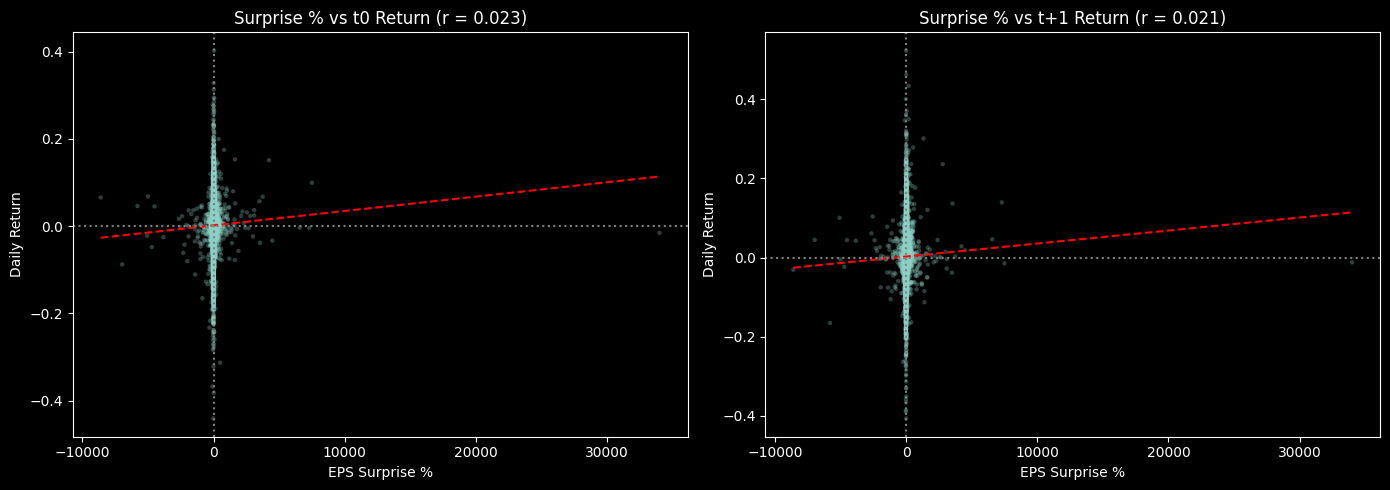

In [19]:
# Larger suprise means larger return?
scatter_data = modeling.select(
    "surprisePercentage", "daily_return_t0", "daily_return_t+1"
).drop_nulls()

sp = scatter_data["surprisePercentage"].to_list()
r0 = scatter_data["daily_return_t0"].to_list()
r1 = scatter_data["daily_return_t+1"].to_list()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ret, title in [
    (axes[0], r0, "Surprise % vs t0 Return"),
    (axes[1], r1, "Surprise % vs t+1 Return"),
]:
    ax.scatter(sp, ret, alpha=0.3, s=10, edgecolors="none")
    z = np.polyfit(sp, ret, 1)
    x_line = np.linspace(min(sp), max(sp), 100)
    ax.plot(x_line, np.polyval(z, x_line), color="red", linestyle="--")
    r_val = np.corrcoef(sp, ret)[0, 1]
    ax.set_title(f"{title} (r = {r_val:.3f})")
    ax.set_xlabel("EPS Surprise %")
    ax.set_ylabel("Daily Return")
    ax.axhline(y=0, color="gray", linestyle=":")
    ax.axvline(x=0, color="gray", linestyle=":")

plt.tight_layout()
plt.show()

### Volume Profile - Beat vs Miss


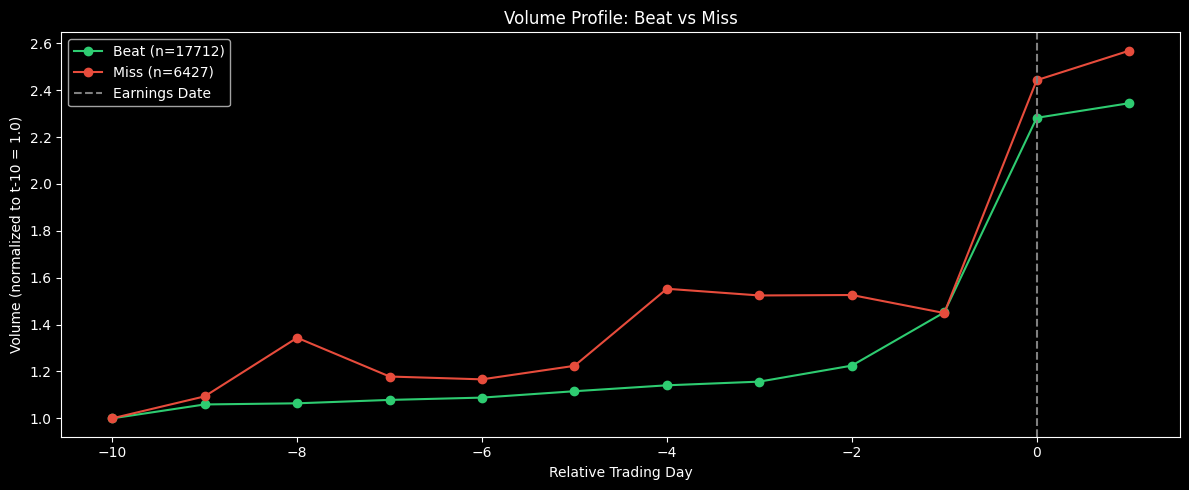

In [20]:
# Normalized volume by beat/miss
volume_cols = sorted(
    [c for c in modeling.columns if c.startswith("volume_t") and "change" not in c],
    key=lambda c: int(c.split("_t")[1].replace("+", ""))
)

fig, ax = plt.subplots(figsize=(12, 5))

for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
    group = modeling.filter(pl.col("beat_flag") == flag)

    vols = group.select(volume_cols).to_numpy().astype(float)
    base = vols[:, 0:1]
    mask = (base > 0).flatten()
    normalized = vols[mask] / base[mask]

    avg_vol = np.mean(normalized, axis=0)
    ax.plot(days, avg_vol, marker="o", label=f"{label} (n={len(normalized)})", color=color)

ax.axvline(x=0, color="gray", linestyle="--", label="Earnings Date")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Volume (normalized to t-10 = 1.0)")
ax.set_title("Volume Profile: Beat vs Miss")
ax.legend()
plt.tight_layout()
plt.show()

### Report Timing - Pre-Market vs Post-Market


Return behavior by announcement timing:
shape: (2, 5)
┌─────────────┬───────┬───────────────┬────────────────┬───────────┐
│ reportTime  ┆ count ┆ avg_return_t0 ┆ avg_return_t+1 ┆ beat_rate │
│ ---         ┆ ---   ┆ ---           ┆ ---            ┆ ---       │
│ str         ┆ u32   ┆ f64           ┆ f64            ┆ f64       │
╞═════════════╪═══════╪═══════════════╪════════════════╪═══════════╡
│ pre-market  ┆ 14362 ┆ 0.002282      ┆ 0.001099       ┆ 0.73792   │
│ post-market ┆ 9799  ┆ 0.001192      ┆ 0.004786       ┆ 0.726094  │
└─────────────┴───────┴───────────────┴────────────────┴───────────┘


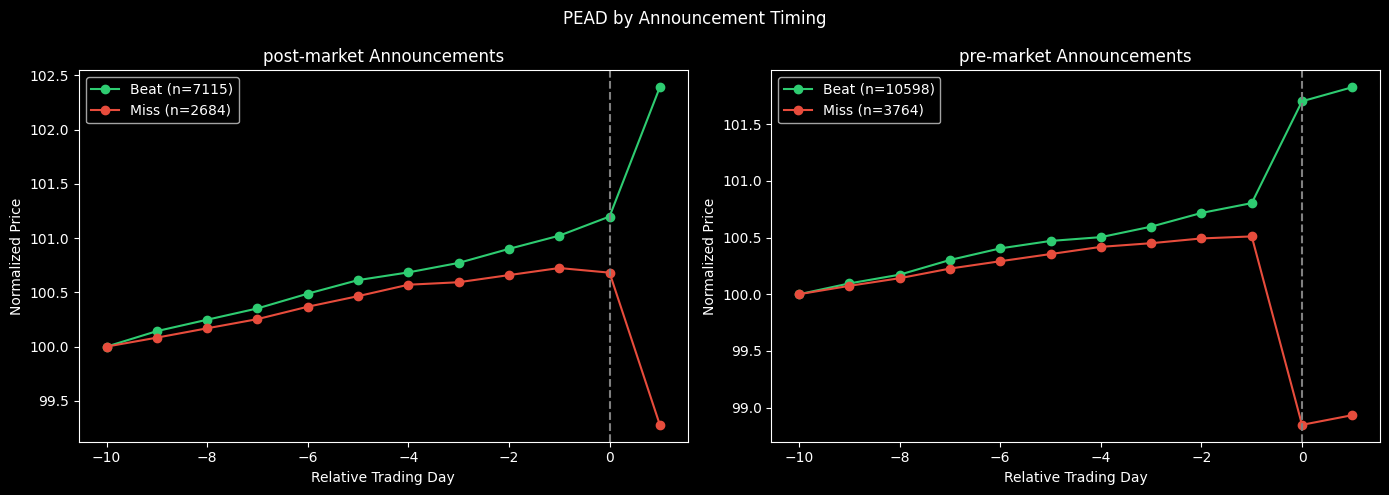

In [21]:
# Report timing analysis 
timing = modeling.group_by("reportTime").agg([
    pl.len().alias("count"),
    pl.col("daily_return_t0").mean().alias("avg_return_t0"),
    pl.col("daily_return_t+1").mean().alias("avg_return_t+1"),
    pl.col("beat_flag").mean().alias("beat_rate"),
])
print("Return behavior by announcement timing:")
print(timing)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, timing_val in zip(axes, modeling["reportTime"].unique().sort().to_list()):
    group = modeling.filter(pl.col("reportTime") == timing_val)
    for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
        sub = group.filter(pl.col("beat_flag") == flag)

        prices = sub.select(close_cols).to_numpy()
        base = prices[:, 0:1]
        mask = (base > 0).flatten()
        normalized = (prices[mask] / base[mask]) * 100

        if len(normalized) > 0:
            ax.plot(days, np.mean(normalized, axis=0), marker="o",
                    label=f"{label} (n={len(normalized)})", color=color)

    ax.axvline(x=0, color="gray", linestyle="--")
    ax.set_title(f"{timing_val} Announcements")
    ax.set_xlabel("Relative Trading Day")
    ax.set_ylabel("Normalized Price")
    ax.legend()

plt.suptitle("PEAD by Announcement Timing")
plt.tight_layout()
plt.show()

### Fiscal Quarter Seasonality

Earnings behavior by fiscal quarter:
shape: (4, 6)
┌─────────┬───────┬───────────┬───────────────┬────────────────┬──────────────┐
│ quarter ┆ count ┆ beat_rate ┆ avg_return_t0 ┆ avg_return_t+1 ┆ avg_surprise │
│ ---     ┆ ---   ┆ ---       ┆ ---           ┆ ---            ┆ ---          │
│ str     ┆ u32   ┆ f64       ┆ f64           ┆ f64            ┆ f64          │
╞═════════╪═══════╪═══════════╪═══════════════╪════════════════╪══════════════╡
│ Q1      ┆ 6295  ┆ 0.740747  ┆ 0.000935      ┆ 0.002323       ┆ 0.102575     │
│ Q2      ┆ 5828  ┆ 0.746225  ┆ 0.00153       ┆ 0.002425       ┆ 0.105259     │
│ Q3      ┆ 5808  ┆ 0.74759   ┆ 0.00231       ┆ 0.003244       ┆ 0.09227      │
│ Q4      ┆ 6230  ┆ 0.699679  ┆ 0.002607      ┆ 0.002421       ┆ 0.087782     │
└─────────┴───────┴───────────┴───────────────┴────────────────┴──────────────┘


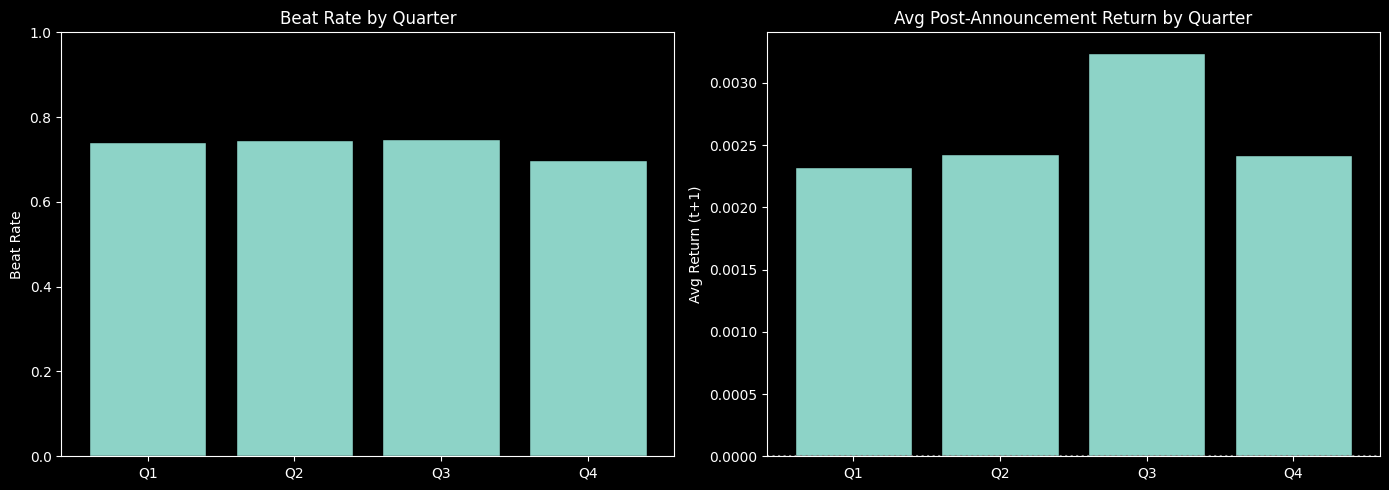

In [22]:
# Seasonality by fiscal quarter
q_analysis = modeling.with_columns(
    pl.col("av_quarter").str.slice(-2).alias("quarter")
).group_by("quarter").agg([
    pl.len().alias("count"),
    pl.col("beat_flag").mean().alias("beat_rate"),
    pl.col("daily_return_t0").mean().alias("avg_return_t0"),
    pl.col("daily_return_t+1").mean().alias("avg_return_t+1"),
    pl.col("surprise").mean().alias("avg_surprise"),
]).sort("quarter")

print("Earnings behavior by fiscal quarter:")
print(q_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
quarters = q_analysis["quarter"].to_list()
axes[0].bar(quarters, q_analysis["beat_rate"].to_list(), edgecolor="black")
axes[0].set_title("Beat Rate by Quarter")
axes[0].set_ylabel("Beat Rate")
axes[0].set_ylim(0, 1)

axes[1].bar(quarters, q_analysis["avg_return_t+1"].to_list(), edgecolor="black")
axes[1].set_title("Avg Post-Announcement Return by Quarter")
axes[1].set_ylabel("Avg Return (t+1)")
axes[1].axhline(y=0, color="gray", linestyle=":")

plt.tight_layout()
plt.show()


### Volatility (ATR) Profile - Beat vs Miss


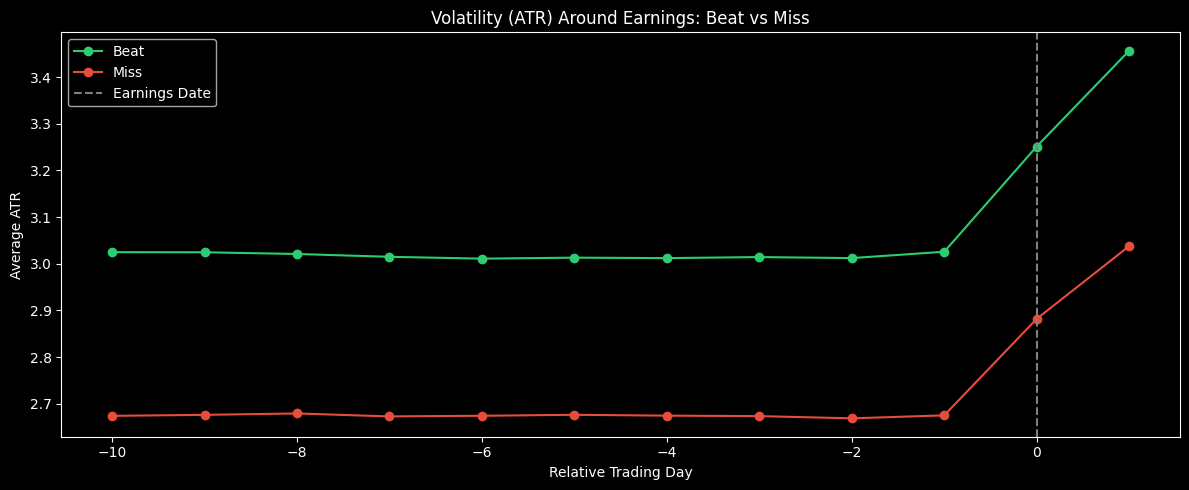

In [23]:
# ATR around earnings
atr_cols = sorted(
    [c for c in modeling.columns if c.startswith("atr_t")],
    key=lambda c: int(c.split("_t")[1].replace("+", ""))
)

fig, ax = plt.subplots(figsize=(12, 5))
for label, flag, color in [("Beat", 1, "#2ecc71"), ("Miss", 0, "#e74c3c")]:
    group = modeling.filter(pl.col("beat_flag") == flag)
    avg_atr = group.select(atr_cols).to_pandas().mean()
    ax.plot(days, avg_atr.values, marker="o", label=label, color=color)

ax.axvline(x=0, color="gray", linestyle="--", label="Earnings Date")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Average ATR")
ax.set_title("Volatility (ATR) Around Earnings: Beat vs Miss")
ax.legend()
plt.tight_layout()
plt.show()


### RSI, MACD, EPS trends, and EPS feature distributions.


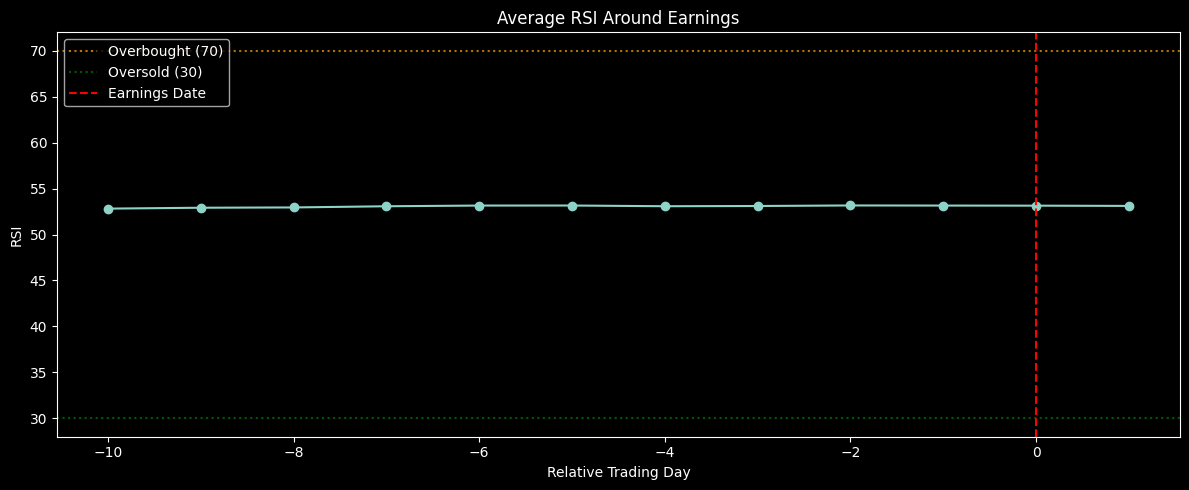

In [24]:
# RSI around earnings
rsi_cols = sorted(
    [c for c in modeling.columns if c.startswith("rsi_t")],
    key=lambda c: int(c.split("_t")[1].replace("+", ""))
)
avg_rsi = modeling.select(rsi_cols).to_pandas().mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(days, avg_rsi.values, marker="o")
ax.axhline(y=70, color="orange", linestyle=":", alpha=0.7, label="Overbought (70)")
ax.axhline(y=30, color="green", linestyle=":", alpha=0.7, label="Oversold (30)")
ax.axvline(x=0, color="red", linestyle="--", label="Earnings Date")
ax.set_title("Average RSI Around Earnings")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("RSI")
ax.legend()
plt.tight_layout()
plt.show()


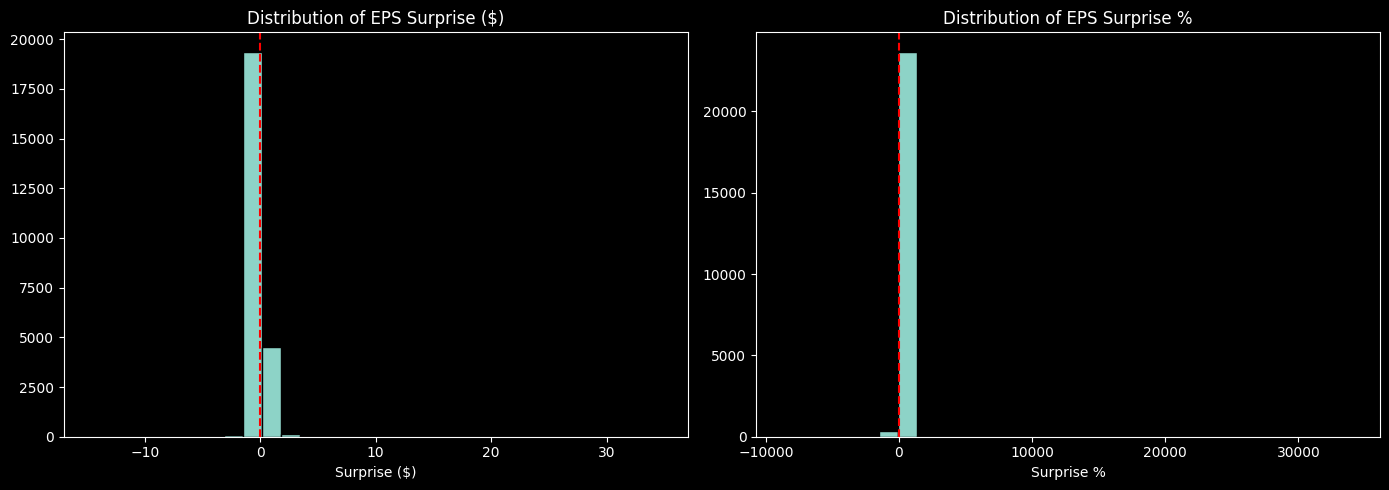

In [25]:
# EPS surprise distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(modeling["surprise"].drop_nulls().to_list(), bins=30, edgecolor="black")
axes[0].axvline(x=0, color="red", linestyle="--")
axes[0].set_title("Distribution of EPS Surprise ($)")
axes[0].set_xlabel("Surprise ($)")

axes[1].hist(modeling["surprisePercentage"].drop_nulls().to_list(), bins=30, edgecolor="black")
axes[1].axvline(x=0, color="red", linestyle="--")
axes[1].set_title("Distribution of EPS Surprise %")
axes[1].set_xlabel("Surprise %")
plt.tight_layout()
plt.show()

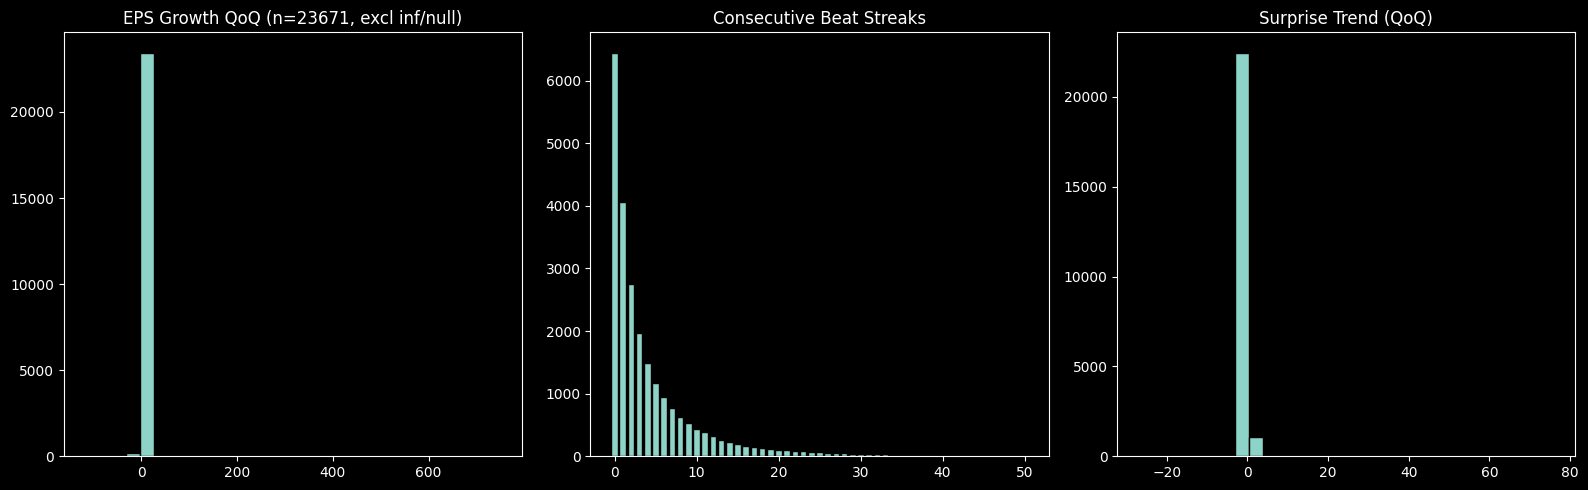

eps_growth: 7 infinite values (prior EPS was $0.00)


In [26]:
# EPS feature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Filter out inf and null
eps_growth_clean = modeling["eps_growth"].filter(
    modeling["eps_growth"].is_finite() & modeling["eps_growth"].is_not_null()
).to_list()

axes[0].hist(eps_growth_clean, bins=30, edgecolor="black")
axes[0].set_title(f"EPS Growth QoQ (n={len(eps_growth_clean)}, excl inf/null)")

vc = modeling["consecutive_beats"].drop_nulls().value_counts().sort("consecutive_beats")
axes[1].bar(vc["consecutive_beats"].to_list(), vc["count"].to_list(), edgecolor="black")
axes[1].set_title("Consecutive Beat Streaks")

axes[2].hist(modeling["surprise_trend"].drop_nulls().to_list(), bins=30, edgecolor="black")
axes[2].set_title("Surprise Trend (QoQ)")
plt.tight_layout()
plt.show()

# Report how many infs were excluded
n_inf = modeling["eps_growth"].is_infinite().sum()
print(f"eps_growth: {n_inf} infinite values (prior EPS was $0.00)")

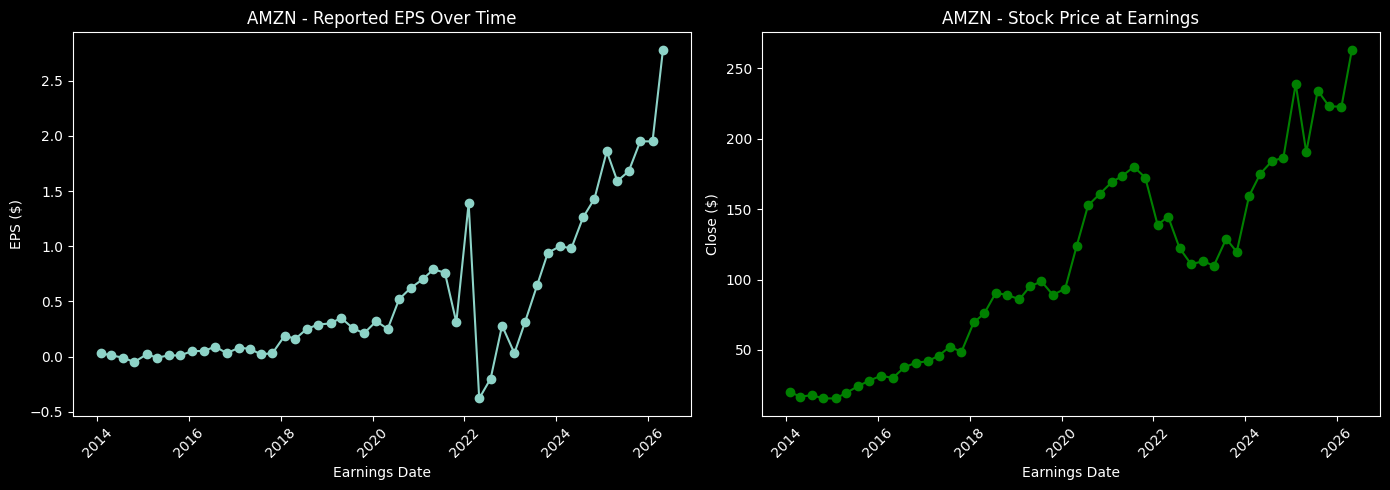

In [28]:
# Temporal trends
# Show one sample stock for temporal trend
sample_sym = "AMZN" if "AMZN" in modeling["symbol"].to_list() else modeling["symbol"][0]
sample = modeling.filter(pl.col("symbol") == sample_sym).sort("earnings_date")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dates = sample["earnings_date"].to_list()

axes[0].plot(dates, sample["reportedEPS"].to_list(), marker="o")
axes[0].set_title(f"{sample_sym} - Reported EPS Over Time")
axes[0].set_xlabel("Earnings Date")
axes[0].set_ylabel("EPS ($)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(dates, sample["close_t0"].to_list(), marker="o", color="green")
axes[1].set_title(f"{sample_sym} - Stock Price at Earnings")
axes[1].set_xlabel("Earnings Date")
axes[1].set_ylabel("Close ($)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Feature Importance - Predictive Signal Assessment

### Beat vs Miss Feature Comparison

In [29]:
# Beat vs miss mean comparison
compare_cols = [c for c in modeling.columns if c.endswith("_t0")] + [
    "surprise", "surprisePercentage", "transcript_word_count"
]
compare_cols = [c for c in compare_cols if c in modeling.columns]

beat_means = modeling.filter(pl.col("beat_flag") == 1).select(compare_cols).mean()
miss_means = modeling.filter(pl.col("beat_flag") == 0).select(compare_cols).mean()

rows = []
for col in compare_cols:
    b, m = beat_means[col][0], miss_means[col][0]
    pct = 100 * (b - m) / abs(m) if m and m != 0 and b is not None else None
    rows.append({"feature": col,
                 "beat_mean": round(b, 4) if b else None,
                 "miss_mean": round(m, 4) if m else None,
                 "pct_diff": round(pct, 1) if pct else None})

print("Feature means: Beat vs Miss (sorted by % difference)")
print(pl.DataFrame(rows).sort("pct_diff", descending=True, nulls_last=True))


Feature means: Beat vs Miss (sorted by % difference)
shape: (21, 4)
┌───────────────────────┬───────────┬───────────┬──────────┐
│ feature               ┆ beat_mean ┆ miss_mean ┆ pct_diff │
│ ---                   ┆ ---       ┆ ---       ┆ ---      │
│ str                   ┆ f64       ┆ f64       ┆ f64      │
╞═══════════════════════╪═══════════╪═══════════╪══════════╡
│ atr_t0                ┆ NaN       ┆ NaN       ┆ NaN      │
│ bb_lower_t0           ┆ NaN       ┆ NaN       ┆ NaN      │
│ bb_middle_t0          ┆ NaN       ┆ NaN       ┆ NaN      │
│ bb_upper_t0           ┆ NaN       ┆ NaN       ┆ NaN      │
│ macd_t0               ┆ NaN       ┆ NaN       ┆ NaN      │
│ …                     ┆ …         ┆ …         ┆ …        │
│ high_t0               ┆ 128.7473  ┆ 109.4505  ┆ 17.6     │
│ open_t0               ┆ 126.1523  ┆ 107.2961  ┆ 17.6     │
│ transcript_word_count ┆ 7575.369  ┆ 7503.624  ┆ 1.0      │
│ intraday_range_t0     ┆ 0.0395    ┆ 0.0406    ┆ -2.7     │
│ volume_t0      

### Mutual Information Ranking


Clean rows for MI: 20201
Mutual Information Ranking (n=20201 events):
shape: (22, 2)
┌───────────────────────┬────────┐
│ feature               ┆ MI     │
│ ---                   ┆ ---    │
│ str                   ┆ f64    │
╞═══════════════════════╪════════╡
│ consecutive_beats     ┆ 0.5741 │
│ surprise_trend        ┆ 0.0892 │
│ eps_growth            ┆ 0.0421 │
│ gap_t0                ┆ 0.0253 │
│ rsi_t0                ┆ 0.0167 │
│ …                     ┆ …      │
│ transcript_word_count ┆ 0.0052 │
│ atr_t0                ┆ 0.0049 │
│ macdhist_t0           ┆ 0.0038 │
│ obv_t0                ┆ 0.0    │
│ volume_t0             ┆ 0.0    │
└───────────────────────┴────────┘


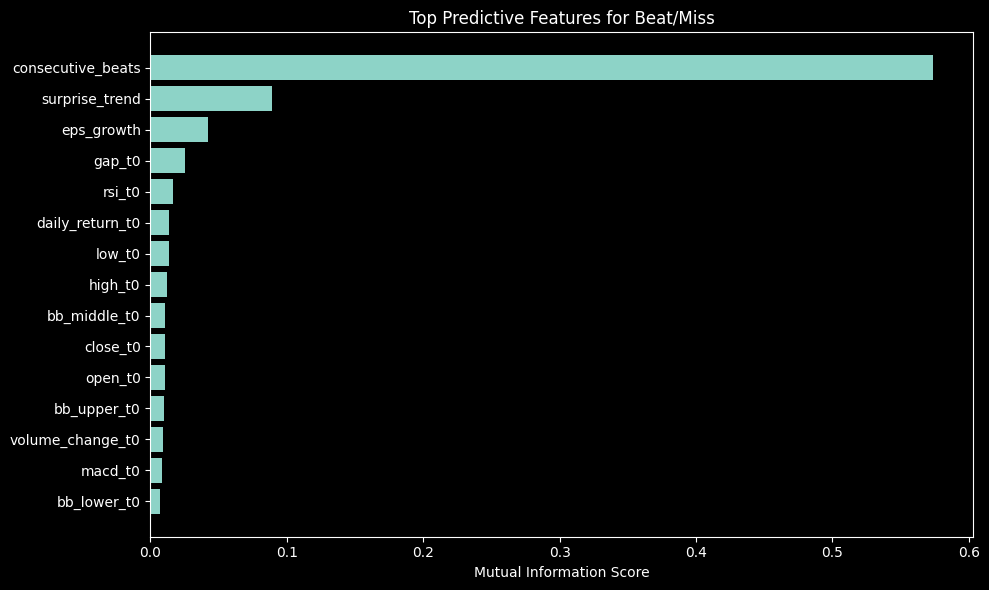

In [30]:
# Mutual information for beat/miss classification
from sklearn.feature_selection import mutual_info_classif

mi_cols = [c for c in modeling.columns if c.endswith("_t0")] + [
    "eps_growth", "surprise_trend", "consecutive_beats", "transcript_word_count"
]
mi_cols = [c for c in mi_cols if c in modeling.columns]

# Handle nulls and infs for MI calculation:
mi_data = (
    modeling.select(mi_cols + ["beat_flag"])
    .with_columns([
        pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
        for c in mi_cols
    ])
    .drop_nulls()
    .to_pandas()
    .dropna()               # catches any numpy NaN that Polars missed
    .reset_index(drop=True)
)

print(f"Clean rows for MI: {len(mi_data)}")

X_mi = mi_data[mi_cols].values
y_mi = mi_data["beat_flag"].values

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pl.DataFrame({"feature": mi_cols, "MI": [round(s, 4) for s in mi_scores]})
mi_df = mi_df.sort("MI", descending=True)

print(f"Mutual Information Ranking (n={len(mi_data)} events):")
print(mi_df)

top_n = min(15, len(mi_df))
top = mi_df.head(top_n)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_n), top["MI"].to_list()[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top["feature"].to_list()[::-1])
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top Predictive Features for Beat/Miss")
plt.tight_layout()
plt.show()

### Pair Plot - Key Features


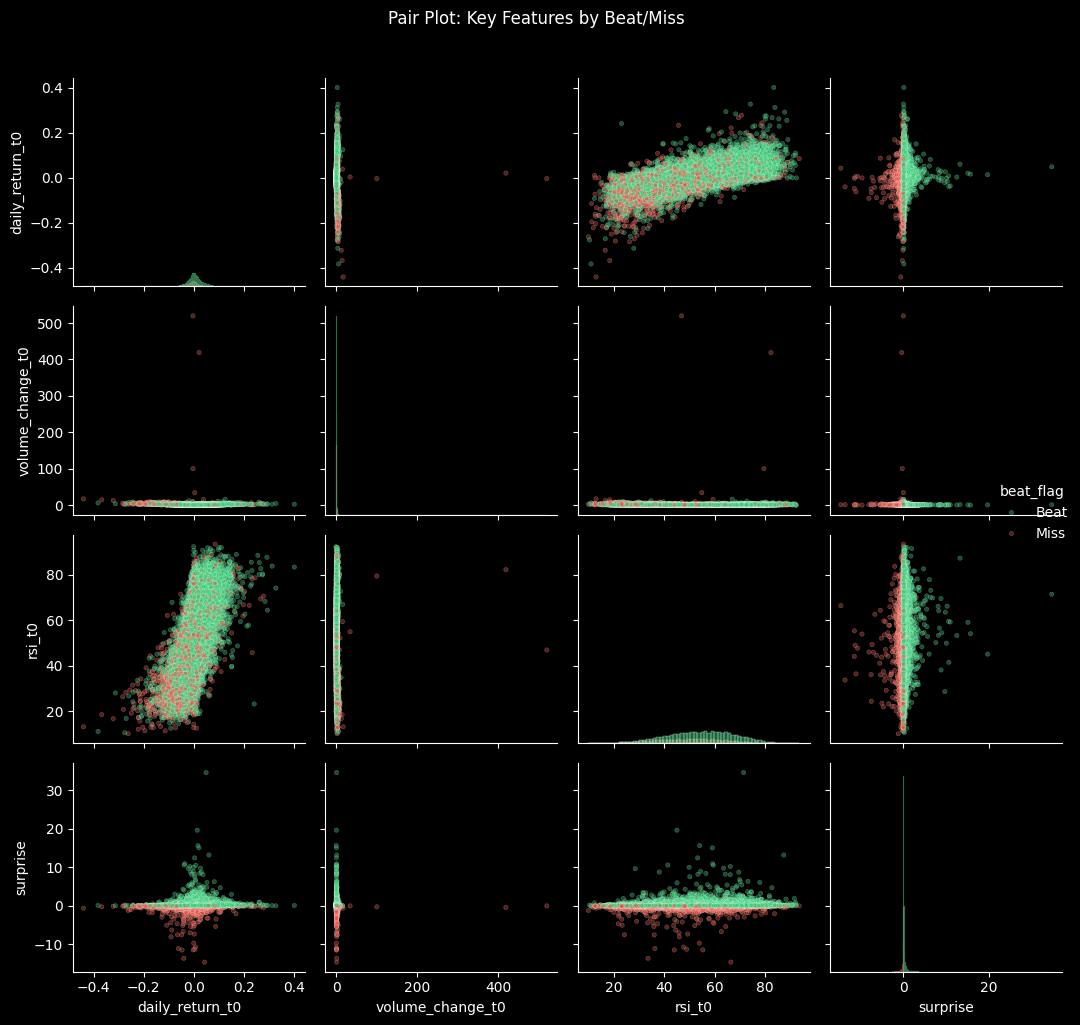

In [31]:
# Pair plot colored by beat/miss
pair_cols = ["daily_return_t0", "volume_change_t0", "rsi_t0", "surprise"]
pair_cols = [c for c in pair_cols if c in modeling.columns]

pair_data = modeling.select(pair_cols + ["beat_flag"]).drop_nulls().to_pandas()
pair_data["beat_flag"] = pair_data["beat_flag"].map({0: "Miss", 1: "Beat"})

g = sns.pairplot(pair_data, hue="beat_flag", diag_kind="hist",
                 palette={"Beat": "#2ecc71", "Miss": "#e74c3c"},
                 plot_kws={"alpha": 0.4, "s": 10})
g.figure.suptitle("Pair Plot: Key Features by Beat/Miss", y=1.02)
plt.tight_layout()
plt.show()


## Transcript Analysis

### Transcript Length Distribution


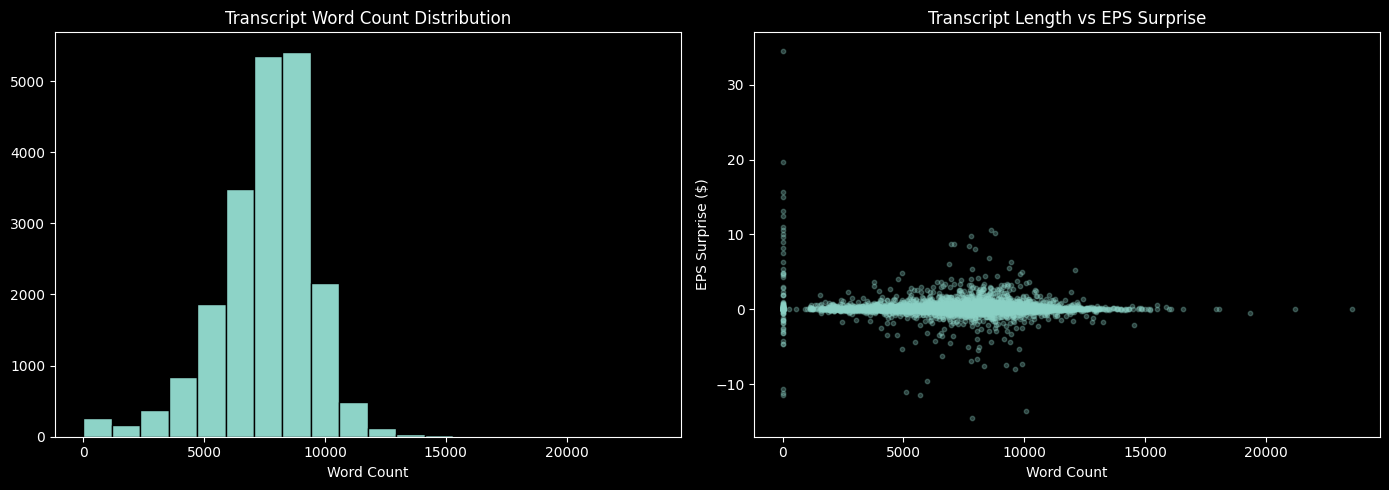

Avg transcript: 7557 words
Shortest: 0
Longest: 23546


In [32]:
# Transcript length analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc = modeling["transcript_word_count"].drop_nulls().to_list()
axes[0].hist(wc, bins=20, edgecolor="black")
axes[0].set_title("Transcript Word Count Distribution")
axes[0].set_xlabel("Word Count")

axes[1].scatter(modeling["transcript_word_count"].to_list(),
                modeling["surprise"].to_list(), alpha=0.3, s=10)
axes[1].set_title("Transcript Length vs EPS Surprise")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("EPS Surprise ($)")
plt.tight_layout()
plt.show()

print(f"Avg transcript: {modeling['transcript_word_count'].mean():.0f} words")
print(f"Shortest: {modeling['transcript_word_count'].min()}")
print(f"Longest: {modeling['transcript_word_count'].max()}")


### Speaker Role Analysis


In [33]:
# Actual transcript content
sample = modeling.filter(pl.col("transcript").is_not_null()).row(0, named=True)
seg = sample["transcript"][0]
print(f"Type: {type(seg)}")
print(f"Keys: {seg.keys() if isinstance(seg, dict) else 'not a dict'}")
print(f"Full segment: {seg}")
print(f"Text value: repr={repr(seg.get('text', 'KEY NOT FOUND'))}")

Type: <class 'dict'>
Keys: dict_keys(['speaker', 'title', 'content', 'sentiment'])
Full segment: {'speaker': 'Alicia Rodriguez', 'title': 'VP, Investor Relations', 'content': "Thank you, operator, and thank you and welcome everyone to Agilent’s first quarter conference call for fiscal year 2014. With me are Bill Sullivan, Agilent’s President and CEO; Ron Nersesian, CEO of Keysight Technologies; and Didier Hirsch, Agilent Senior Vice President and CFO. Joining in the Q&A after Didier's comments will be the presidents of our chemical analysis and life sciences and diagnostics groups, Mike McMullen and Fred Strohmeier. Also joining from Keysight will be Neil Dougherty, CFO; and Guy Séné, Senior Vice President of R&D and Sales. You can find the press release and information to supplement today's discussion on our website at www.investor.agilent.com. While there, please click on the link for Financial Results under the Financial Information tab. There you will find an investor presentation 

Speaker role breakdown:
shape: (6, 4)
┌───────────────┬──────────┬─────────────┬────────────┐
│ role          ┆ segments ┆ total_words ┆ avg_words  │
│ ---           ┆ ---      ┆ ---         ┆ ---        │
│ str           ┆ u32      ┆ i64         ┆ f64        │
╞═══════════════╪══════════╪═════════════╪════════════╡
│ CEO/President ┆ 439667   ┆ 82129143    ┆ 186.798516 │
│ CFO/Finance   ┆ 157903   ┆ 34403350    ┆ 217.876481 │
│ Analyst       ┆ 462300   ┆ 25418908    ┆ 54.983578  │
│ Other         ┆ 44855    ┆ 7253272     ┆ 161.704871 │
│ Operator      ┆ 211349   ┆ 4324395     ┆ 20.46092   │
│ IR            ┆ 19229    ┆ 2112667     ┆ 109.868792 │
└───────────────┴──────────┴─────────────┴────────────┘


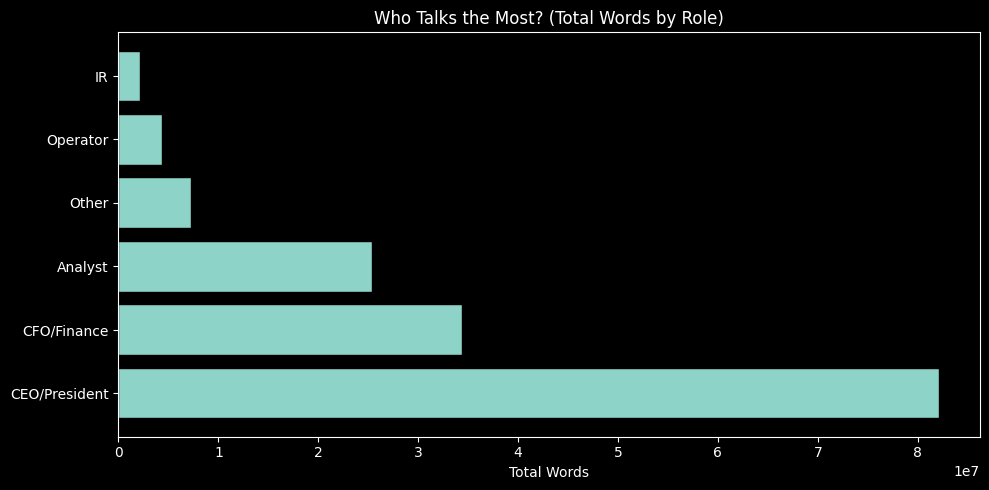

In [34]:
# Speaker role breakdown
speaker_stats = []
for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript")
    if transcript is None:
        continue
    for seg in transcript:
        if not isinstance(seg, dict):
            continue
        speaker_stats.append({
            "symbol": row["symbol"],
            "title": seg.get("title", "Unknown"),
            "word_count": len(seg.get("content", "").split()),  
        })

speaker_df = pl.DataFrame(speaker_stats)

# Classify roles
speaker_df = speaker_df.with_columns(
    pl.when(pl.col("title").str.to_lowercase().str.contains("ceo|chief executive|president"))
      .then(pl.lit("CEO/President"))
    .when(pl.col("title").str.to_lowercase().str.contains("cfo|chief financial|finance"))
      .then(pl.lit("CFO/Finance"))
    .when(pl.col("title").str.to_lowercase().str.contains("analyst|research|managing director"))
      .then(pl.lit("Analyst"))
    .when(pl.col("title").str.to_lowercase().str.contains("operator"))
      .then(pl.lit("Operator"))
    .when(pl.col("title").str.to_lowercase().str.contains("investor relation"))
      .then(pl.lit("IR"))
    .otherwise(pl.lit("Other"))
    .alias("role")
)

role_summary = speaker_df.group_by("role").agg([
    pl.len().alias("segments"),
    pl.col("word_count").sum().alias("total_words"),
    pl.col("word_count").mean().alias("avg_words"),
]).sort("total_words", descending=True)

print("Speaker role breakdown:")
print(role_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(role_summary["role"].to_list(), role_summary["total_words"].to_list(), edgecolor="black")
ax.set_xlabel("Total Words")
ax.set_title("Who Talks the Most? (Total Words by Role)")
plt.tight_layout()
plt.show()

### Prepared Remarks vs Q&A Split

Prepared vs Q&A split:
shape: (9, 4)
┌────────────┬────────────────┬─────────────┬──────────────┐
│ statistic  ┆ prepared_words ┆ qa_words    ┆ prepared_pct │
│ ---        ┆ ---            ┆ ---         ┆ ---          │
│ str        ┆ f64            ┆ f64         ┆ f64          │
╞════════════╪════════════════╪═════════════╪══════════════╡
│ count      ┆ 24161.0        ┆ 24161.0     ┆ 24161.0      │
│ null_count ┆ 0.0            ┆ 0.0         ┆ 0.0          │
│ mean       ┆ 1485.943421    ┆ 4955.914739 ┆ 20.000592    │
│ std        ┆ 1816.998195    ┆ 3096.27677  ┆ 23.93312     │
│ min        ┆ 0.0            ┆ 0.0         ┆ 0.0          │
│ 25%        ┆ 0.0            ┆ 2928.0      ┆ 0.0          │
│ 50%        ┆ 56.0           ┆ 5135.0      ┆ 0.8          │
│ 75%        ┆ 2881.0         ┆ 7381.0      ┆ 39.1         │
│ max        ┆ 14945.0        ┆ 23546.0     ┆ 100.0        │
└────────────┴────────────────┴─────────────┴──────────────┘


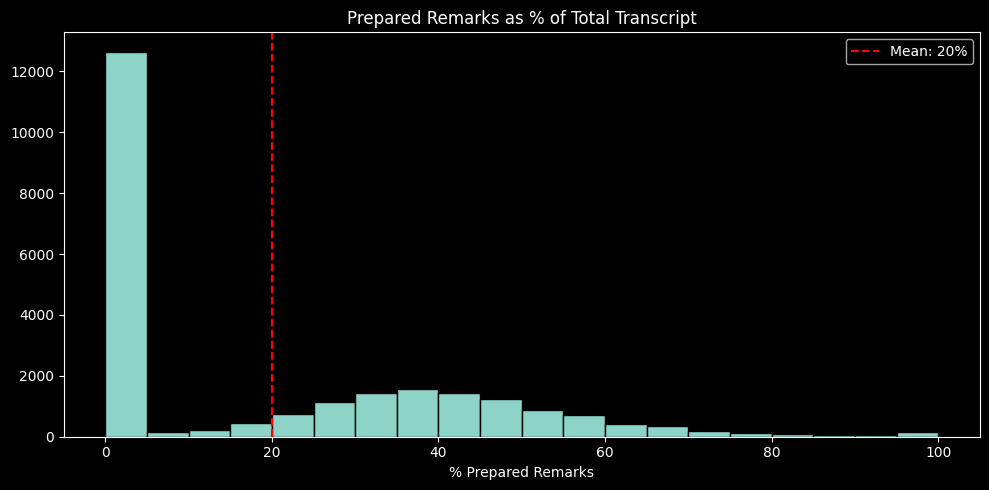

In [35]:
# Detect prepared remarks vs Q&A
def split_sections(transcript):
    if not transcript or len(transcript) == 0:
        return "", "", -1
    
    qa_start = None
    for i, seg in enumerate(transcript):
        if not isinstance(seg, dict):
            continue
        content_lower = seg.get("content", "").lower()
        title_lower = seg.get("title", "").lower()
        if any(m in content_lower for m in [
            "open the call for questions", "open it up for questions",
            "first question", "begin the question", "q&a session",
            "question-and-answer",
        ]):
            qa_start = i
            break
        if i > 3 and "operator" in title_lower and "question" in content_lower:
            qa_start = i
            break
    
    if qa_start is None:
        qa_start = max(1, int(len(transcript) * 0.4))
    
    prep = " ".join([s.get("content", "") if isinstance(s, dict) else str(s) for s in transcript[:qa_start]])
    qa = " ".join([s.get("content", "") if isinstance(s, dict) else str(s) for s in transcript[qa_start:]])
    return prep, qa, qa_start


section_stats = []
for row in modeling.iter_rows(named=True):
    prep, qa, idx = split_sections(row.get("transcript"))
    total = len(prep.split()) + len(qa.split())
    section_stats.append({
        "symbol": row["symbol"],
        "prepared_words": len(prep.split()),
        "qa_words": len(qa.split()),
        "prepared_pct": round(100 * len(prep.split()) / max(1, total), 1),
    })

sect_df = pl.DataFrame(section_stats)
print("Prepared vs Q&A split:")
print(sect_df.select("prepared_words", "qa_words", "prepared_pct").describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sect_df["prepared_pct"].to_list(), bins=20, edgecolor="black")
ax.axvline(x=sect_df["prepared_pct"].mean(), color="red", linestyle="--",
           label=f"Mean: {sect_df['prepared_pct'].mean():.0f}%")
ax.set_title("Prepared Remarks as % of Total Transcript")
ax.set_xlabel("% Prepared Remarks")
ax.legend()
plt.tight_layout()
plt.show()

### Sentence-Level Stats

In [36]:
# Sentence-level analysis
sentence_stats = []

for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript", [])
    text = " ".join([seg.get("content", "") if isinstance(seg, dict) else str(seg) for seg in (transcript or [])])
    if not text.strip():
        continue
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', text)
    word_counts = [len(s.split()) for s in sentences]
    token_est = [int(w * 1.3) for w in word_counts]
    
    sentence_stats.append({
        "num_sentences": len(sentences),
        "avg_words": round(np.mean(word_counts), 1),
        "max_words": max(word_counts),
        "over_384_tokens": sum(1 for t in token_est if t > 384),
        "total_tokens": sum(token_est),
    })

sent_df = pl.DataFrame(sentence_stats)
print("Sentence-level statistics:")
print(sent_df.describe())

total_sent = sent_df["num_sentences"].sum()
total_tok = sent_df["total_tokens"].sum()
over = sent_df["over_384_tokens"].sum()

print(f"\n- FinBERT Compute Estimate -")
print(f"Total sentences: {total_sent:,}")
print(f"Total tokens: {total_tok:,}")
print(f"Sentences needing truncation (>384 tokens): {over:,}")
print(f"Estimated batches (batch_size=32): {total_sent // 32 + 1:,}")

Sentence-level statistics:
shape: (9, 6)
┌────────────┬───────────────┬───────────┬───────────┬─────────────────┬──────────────┐
│ statistic  ┆ num_sentences ┆ avg_words ┆ max_words ┆ over_384_tokens ┆ total_tokens │
│ ---        ┆ ---           ┆ ---       ┆ ---       ┆ ---             ┆ ---          │
│ str        ┆ f64           ┆ f64       ┆ f64       ┆ f64             ┆ f64          │
╞════════════╪═══════════════╪═══════════╪═══════════╪═════════════════╪══════════════╡
│ count      ┆ 20339.0       ┆ 20339.0   ┆ 20339.0   ┆ 20339.0         ┆ 20339.0      │
│ null_count ┆ 0.0           ┆ 0.0       ┆ 0.0       ┆ 0.0             ┆ 0.0          │
│ mean       ┆ 435.606372    ┆ 17.707159 ┆ 72.936231 ┆ 0.000836        ┆ 9749.274841  │
│ std        ┆ 107.693626    ┆ 2.117107  ┆ 20.584631 ┆ 0.032122        ┆ 2359.806594  │
│ min        ┆ 21.0          ┆ 8.8       ┆ 26.0      ┆ 0.0             ┆ 346.0        │
│ 25%        ┆ 372.0         ┆ 16.3      ┆ 60.0      ┆ 0.0             ┆ 8394.0

### Boilerplate / Legal Disclaimer Detection


In [37]:
# Boilerplate detection
bp_patterns = [
    "forward-looking statement", "safe harbor", "actual results may differ",
    "risk factors", "non-gaap", "this call is being recorded",
    "all participants are in listen-only", "sec filing", "regulation fd",
]

bp_stats = []
for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript")
    if transcript is None:
        continue
    bp_words, total_words = 0, 0
    for seg in transcript:
        text = seg.get("content", "") if isinstance(seg, dict) else str(seg)
        words = len(text.split())
        total_words += words
        if any(p in text.lower() for p in bp_patterns):
            bp_words += words
    bp_stats.append({
        "bp_words": bp_words,
        "total_words": total_words,
        "bp_pct": round(100 * bp_words / max(1, total_words), 1),
    })

bp_df = pl.DataFrame(bp_stats)
print(f"Boilerplate analysis:")
print(f"  Avg boilerplate: {bp_df['bp_pct'].mean():.1f}% of transcript")
print(f"  Max boilerplate: {bp_df['bp_pct'].max():.1f}%")
print(f"  Recommendation: strip legal disclaimers before FinBERT inference")

Boilerplate analysis:
  Avg boilerplate: 9.2% of transcript
  Max boilerplate: 97.9%
  Recommendation: strip legal disclaimers before FinBERT inference


### Existing Sentiment Field Check


In [38]:
# Check for pre-existing sentiment in transcript data
total_with, total_without = 0, 0
all_sentiments = []

for row in modeling.iter_rows(named=True):
    transcript = row.get("transcript")
    if transcript is None:
        continue
    for seg in transcript:
        if not isinstance(seg, dict):
            continue
        sent = seg.get("sentiment")
        if sent and sent != "" and sent != "N/A":
            total_with += 1
            all_sentiments.append(sent)
        else:
            total_without += 1

print(f"Pre-existing sentiment coverage:")
print(f"  With sentiment:    {total_with:,}")
print(f"  Without sentiment: {total_without:,}")
print(f"  Coverage: {100 * total_with / max(1, total_with + total_without):.1f}%")

if total_with > 0:
    dist = pl.Series("sentiment", all_sentiments).value_counts().sort("count", descending=True)
    print(f"\nSentiment distribution:")
    print(dist)
else:
    print("\nNo pre-existing sentiment — FinBERT will compute from scratch")


Pre-existing sentiment coverage:
  With sentiment:    1,335,303
  Without sentiment: 0
  Coverage: 100.0%

Sentiment distribution:
shape: (20, 2)
┌───────────┬────────┐
│ sentiment ┆ count  │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ 0.0       ┆ 559202 │
│ 0.2       ┆ 149548 │
│ 0.5       ┆ 126549 │
│ 0.1       ┆ 111904 │
│ 0.3       ┆ 110161 │
│ …         ┆ …      │
│ 1.0       ┆ 86     │
│ -0.6      ┆ 60     │
│ -0.0      ┆ 57     │
│ -0.7      ┆ 15     │
│ -0.8      ┆ 5      │
└───────────┴────────┘


## Dimensionality Reduction Analysis

PCA input (after dropping inf/NaN rows): (24042, 216)


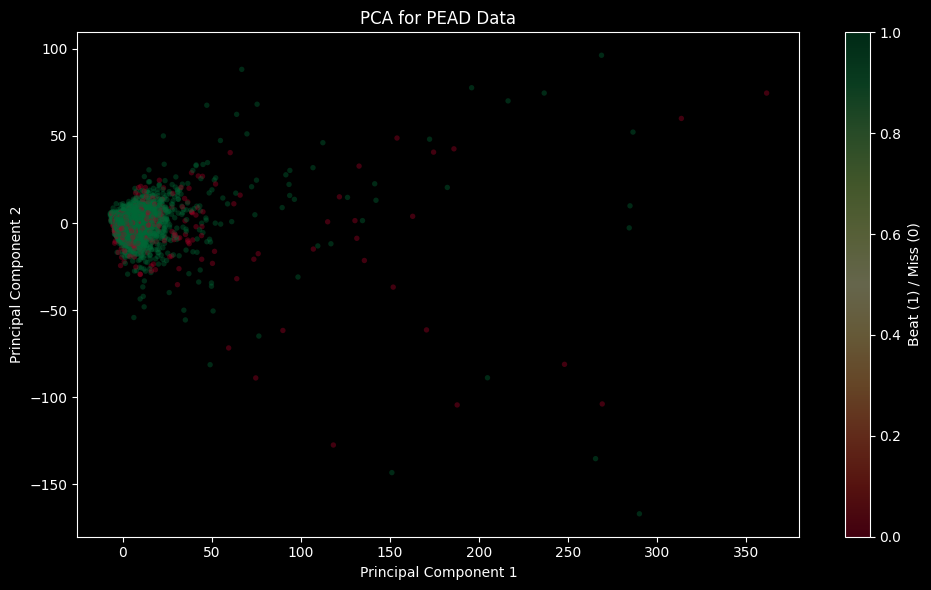

Eigenvalues (first 2): [96.10820407 22.72653492]

Direction of the first two PCs (eigenvectors):
 [[ 9.57583630e-02  1.01343249e-01  1.01485683e-01  1.01523616e-01
   1.01713769e-01  9.47199184e-04  6.80311232e-04  1.01723494e-01
   1.80926424e-03  1.01694020e-01  1.86778622e-02  1.08438057e-02
   1.54864887e-02 -3.04582162e-03  1.01695477e-01  4.32075038e-03
  -1.04350572e-03 -6.85521984e-03  9.56358379e-02  1.01363887e-01
   1.01511487e-01  1.01551711e-01  1.01741563e-01  9.97753197e-04
   1.21926394e-03  1.01748450e-01  1.52436676e-03  1.01721756e-01
   1.94702528e-02  9.60006127e-03  1.64892715e-02 -3.04600741e-03
   1.01727969e-01  4.41740489e-03 -8.53267024e-04 -6.83946812e-03
   9.56534824e-02  1.01388861e-01  1.01540368e-01  1.01582201e-01
   1.01787921e-01  1.62659391e-03  1.04573289e-03  1.01779143e-01
   1.41064036e-03  1.01750192e-01  2.15575666e-02  1.20400396e-02
   1.77413058e-02 -3.04672609e-03  1.01740812e-01  4.86407898e-03
  -7.33142593e-04 -6.89798503e-03  9.5711311

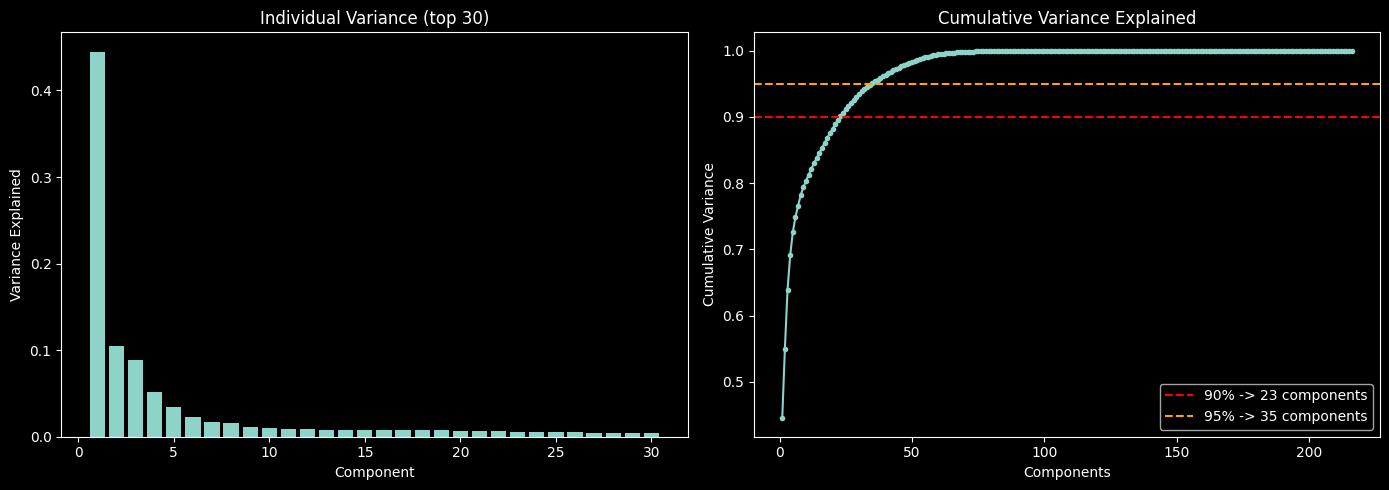

Original features:       216
Components for 90% var:  23  (89% reduction)
Components for 95% var:  35  (84% reduction)


In [51]:
# PCA on pivoted columns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare data — replace inf with NaN, drop incomplete rows
pca_data = modeling.select(pivoted_cols).to_pandas()
pca_data = pca_data.replace([np.inf, -np.inf], np.nan).dropna()
print(f"PCA input (after dropping inf/NaN rows): {pca_data.shape}")

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Perform PCA (map 216-dimensional space to 2D for visualization)
pca = PCA(n_components=2)
pca.fit(scaled_data)
transformed_data = pca.transform(scaled_data)

# Get beat/miss labels aligned to the cleaned rows
labels = modeling.select("beat_flag").to_pandas().loc[pca_data.index, "beat_flag"].values

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(transformed_data[:, 0], transformed_data[:, 1],
            c=labels, cmap="RdYlGn", alpha=0.4, s=15, edgecolors="none")
plt.colorbar(label="Beat (1) / Miss (0)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA for PEAD Data")
plt.tight_layout()
plt.show()

# PCA outputs
eigen_values = pca.explained_variance_
eigen_vectors = pca.components_
variance = pca.explained_variance_ratio_

print("Eigenvalues (first 2):", eigen_values)
print("\nDirection of the first two PCs (eigenvectors):\n", eigen_vectors)
print("\nVariance ratio for the first two PCs:", variance)
print("\nTotal variance captured:", round(variance.sum(), 4))

# retain components
pca_full = PCA()
pca_full.fit(scaled_data)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = int(np.argmax(cum_var >= 0.90) + 1)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_) + 1)),
            pca_full.explained_variance_ratio_[:30])
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance Explained")
axes[0].set_title("Individual Variance (top 30)")

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker=".")
axes[1].axhline(y=0.90, color="red", linestyle="--", label=f"90% -> {n_90} components")
axes[1].axhline(y=0.95, color="orange", linestyle="--", label=f"95% -> {n_95} components")
axes[1].set_xlabel("Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Original features:       {len(pivoted_cols)}")
print(f"Components for 90% var:  {n_90}  ({100*(1 - n_90/len(pivoted_cols)):.0f}% reduction)")
print(f"Components for 95% var:  {n_95}  ({100*(1 - n_95/len(pivoted_cols)):.0f}% reduction)")

In [52]:
# Correlation-based feature selection
corr_abs = pca_data.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f"Correlation-based selection (threshold=0.95):")
print(f"  Highly correlated: {len(high_corr)}")
print(f"  Remaining: {len(pivoted_cols) - len(high_corr)}")
print(f"\nComparison:")
print(f"  Original:          {len(pivoted_cols)}")
print(f"  After PCA (90%):   {n_90}")
print(f"  After corr filter: {len(pivoted_cols) - len(high_corr)}")


Correlation-based selection (threshold=0.95):
  Highly correlated: 141
  Remaining: 75

Comparison:
  Original:          216
  After PCA (90%):   23
  After corr filter: 75


In [53]:
# Preprocessing readiness summary
print("Preprocessing Readiness Checklist")
print("-" * 55)

n_events = modeling.shape[0]
total_nulls = modeling.null_count().sum_horizontal()[0]
null_pct = 100 * total_nulls / (n_events * modeling.shape[1])

# Inf counts in pivoted columns
inf_count = 0
for c in pivoted_cols:
    inf_count += modeling.select(pl.col(c).is_infinite().sum())[0, 0]

print(f"Events:              {n_events:,}")
print(f"Features:            {modeling.shape[1]}")
print(f"Total nulls:         {total_nulls:,} ({null_pct:.2f}%)")
print(f"Total infs (pivoted):{inf_count:,}")
print(f"Beat/miss ratio:     {modeling['beat_flag'].mean():.1%} / {1 - modeling['beat_flag'].mean():.1%}")
print(f"Low-event stocks:    {modeling.group_by('symbol').len().filter(pl.col('len') < 10).shape[0]}")
print(f"PCA target:          216 pivoted -> ~{n_90} components (90% var)")

Preprocessing Readiness Checklist
-------------------------------------------------------
Events:              24,161
Features:            237
Total nulls:         11,878 (0.21%)
Total infs (pivoted):91
Beat/miss ratio:     73.3% / 26.7%
Low-event stocks:    4
PCA target:          216 pivoted -> ~23 components (90% var)


### Checks on Transcripts

In [55]:
# Pick a known transcript and print the first 3 segments
sample = modeling.filter(
    (pl.col("symbol") == "AMZN") & pl.col("transcript").is_not_null()
).row(0, named=True)

for seg in sample["transcript"][:3]:
    print(f"Speaker: {seg.get('speaker', 'N/A')}")
    print(f"Title:   {seg.get('title', 'N/A')}")
    print(f"Content: {seg.get('content', 'MISSING KEY')[:200]}...")
    print(f"Sentiment: {seg.get('sentiment', 'N/A')}")
    print("-" * 60)

Speaker: Cindy McCann
Title:   Vice President, Investor Relations
Content: Good afternoon and thank you for joining us. On today’s call are John Mackey and Walter Robb, Co-Chief Executive Officers; A.C. Gallo, President; Glenda Flanagan, Executive Vice President and Chief Fi...
Sentiment: 0.5
------------------------------------------------------------
Speaker: John Mackey
Title:   Co-Chief Executive Officer
Content: Thank you, Cindy. Good afternoon, everyone. We delivered record fourth quarter results including 12 store openings, average weekly sales per store of $694,000 translating to sales per gross square foo...
Sentiment: 0.9
------------------------------------------------------------
Speaker: Operator
Title:   Operator
Content: Thank you. (Operator Instructions) We will take our first question from Charles Grom with Sterne Agee. Please go ahead....
Sentiment: 0.0
------------------------------------------------------------


In [56]:
# Find a specific AMZN earnings call you can verify online
check = modeling.filter(
    (pl.col("symbol") == "AMZN") & (pl.col("earnings_date") == pl.date(2024, 2, 1))
)
if check.shape[0] > 0:
    transcript = check.row(0, named=True)["transcript"]
    print(f"Segments: {len(transcript)}")
    print(f"First speaker: {transcript[0].get('speaker', '')} - {transcript[0].get('title', '')}")
    print(f"First 300 chars: {transcript[0].get('content', '')[:300]}")

Segments: 27
First speaker: Operator - Operator
First 300 chars: Thank you for standing by. Good day everyone and welcome to the Amazon.com Fourth Quarter 2023 Financial Results Teleconference. Operator Instructions: Today's call is being recorded. For opening remarks, I will be turning the call over to the Vice President of Investor Relations, Mr. Dave Fildes. T


In [57]:
# Word counts should be roughly 5,000-12,000 for a typical earnings call
wc_stats = modeling.filter(pl.col("transcript").is_not_null()).select(
    "symbol", "earnings_date", "transcript_word_count"
)

print(f"Transcripts with word count = 0: {wc_stats.filter(pl.col('transcript_word_count') == 0).shape[0]}")
print(f"Transcripts under 1,000 words:  {wc_stats.filter(pl.col('transcript_word_count') < 1000).shape[0]}")
print(f"Transcripts over 20,000 words:  {wc_stats.filter(pl.col('transcript_word_count') > 20000).shape[0]}")
print(f"\nWord count distribution:")
print(wc_stats.select("transcript_word_count").describe())

# Show any suspiciously short ones
short = wc_stats.filter(pl.col("transcript_word_count") < 500).sort("transcript_word_count")
if short.shape[0] > 0:
    print(f"\n⚠ {short.shape[0]} transcripts under 500 words:")
    print(short.head(10))

Transcripts with word count = 0: 178
Transcripts under 1,000 words:  181
Transcripts over 20,000 words:  2

Word count distribution:
shape: (9, 2)
┌────────────┬───────────────────────┐
│ statistic  ┆ transcript_word_count │
│ ---        ┆ ---                   │
│ str        ┆ f64                   │
╞════════════╪═══════════════════════╡
│ count      ┆ 20517.0               │
│ null_count ┆ 0.0                   │
│ mean       ┆ 7585.988936           │
│ std        ┆ 1972.51904            │
│ min        ┆ 0.0                   │
│ 25%        ┆ 6543.0                │
│ 50%        ┆ 7825.0                │
│ 75%        ┆ 8856.0                │
│ max        ┆ 23546.0               │
└────────────┴───────────────────────┘

⚠ 179 transcripts under 500 words:
shape: (10, 3)
┌────────┬───────────────┬───────────────────────┐
│ symbol ┆ earnings_date ┆ transcript_word_count │
│ ---    ┆ ---           ┆ ---                   │
│ str    ┆ date          ┆ i64                   │
╞════════╪═══

In [59]:
# checks if the transcript info is missing with the quarter and year

missing_transcripts = modeling.filter(
    pl.col("transcript").is_null() | (pl.col("transcript_word_count") == 0)
).select("symbol", "earnings_date", "av_quarter", "fiscal_year")

In [64]:
missing_transcripts

symbol,earnings_date,av_quarter,fiscal_year
str,date,str,i32
"""A""",2026-05-27,"""2026Q2""",2026
"""AAPL""",2014-01-27,"""2013Q4""",2013
"""AAPL""",2014-04-23,"""2014Q1""",2014
"""AAPL""",2014-07-22,"""2014Q2""",2014
"""AAPL""",2014-10-20,"""2014Q3""",2014
…,…,…,…
"""ZTS""",2021-08-05,"""2021Q2""",2021
"""ZTS""",2021-11-04,"""2021Q3""",2021
"""ZTS""",2022-02-15,"""2021Q4""",2021


In [66]:
# count how many missing transcripts there are by quarter and year
missing_summary = missing_transcripts.group_by("symbol", "fiscal_year").agg(
    pl.len().alias("missing_count")
).sort(["symbol", "fiscal_year"])

missing_summary.sum()

symbol,fiscal_year,missing_count
str,i32,u32
null,2435690,3822
